# HW02-1：股票收益与组合风险分析

| 项目 | 内容 |
|---|---|
| 姓名 | 魏致衡 |
| 学号 | LN429 |
| 课程 / 教师 | LN429 金融计量 / 连玉君 |
| 作业页面 | <https://lianxhcn.github.io/FinEco/exercises/hw-02.html> |
| GitHub 仓库 | <https://github.com/lh3536/FinEco-hw> |
| HW02-1 目录 | <https://github.com/lh3536/FinEco-hw/tree/main/hw02-1> |
| HW02-2 目录 | <https://github.com/lh3536/FinEco-hw/tree/main/hw02-2> |
| 数据来源 | CSMAR（中山大学授权）：日个股回报率文件 `TRD_Dalyr`（两次导出，2020-12-01—2025-11-28 与 2025-12-01—2026-09-16）；上市公司基本信息年度表 `STK_LISTEDCOINFOANL`（行业、上市日期） |
| 下载日期 | 2026-09-28 |
| 样本期 | 2021-01-01—2026-09-16（首个交易日 2021-01-04，共 1,384 个交易日）；保留 2020-12 的记录，用作首日收益与首日 t−1 市值的基准 |

**数据源说明。** 官方页面建议优先使用 AKShare，但也允许使用 CSMAR，前提是说明原因。本作业使用 CSMAR，原因有两点：`Dretwd`（考虑现金红利再投资的日回报率）与用复权收盘价计算的简单收益率口径一致；`Dsmvtll` 直接提供每日的历史总市值，可以用来构造 t−1 市值权重。

**AI 使用声明**

- **使用的工具：** ChatGPT / Codex（OpenAI）与 Claude（Anthropic，Cowork 模式）。
- **参与环节：**
  - 原始压缩包的识别与字段审计；
  - 代码编写与调试；
  - 图表绘制；
  - Notebook 结构与文字初稿。

  两个工具**各自独立完成了一个版本**，随后由 Claude 对照官方评分标准做交叉审计，并合并成本版本。
- **关键提示词（摘录）：**
  - “Market-cap-weighted portfolio weights must use t−1 market capitalization, NOT same-day t market capitalization.”
  - “Do NOT silently drop unreadable files or malformed rows.”
- **核验与修正：**
  - 两个独立版本的关键结果完全一致：等权组合期末净值 1.093、年化 1.63%、波动 17.54%、最大回撤 22.67%；市值加权组合依次为 1.030、0.54%、18.63%、35.68%。
  - 代码中用 `assert` 核对行数、键唯一性、权重和与几何年化；另外用独立脚本重算了组合指标。
  - 交叉审计后修正了三处：
    1. 复牌日的多日累计收益原先被当作单日收益，计入了标准差、滚动波动和相关系数，现已从这些统计中剔除；
    2. 累计收益图改为起点为 1 的净值曲线；
    3. 滚动波动改为严格的 20 个连续交易日窗口，窗口不完整时不计算。

  所有数字都来自下方代码的实际输出。

## 分析目标与思路

本作业考察 10 只覆盖 9 个证监会门类的 A 股大盘股在 2021-01-04 至 2026-09-16 的收益、风险与相关性，并比较**等权组合**与**滞后一期总市值加权组合**的表现。分析按以下顺序展开：数据审计 → 质量检查 → 收益构造 → 个股图形与统计 → 组合构建 → 绩效比较 → 结论。

- **收益率。** 用复权口径的 `Dretwd`；不复权收盘价 `Clsprc` 只用于价格图和核对。
- **停牌。** 停牌日既不删除，也不一律填 0。持仓期收益的做法是：停牌日持仓价值不变，复牌日的 `Dretwd` 计入整个停牌期间的价格变化。单日收益统计中，**剔除复牌日**，因为那一天的收益是多日累计的。
- **组合（官方教学设定）。** 每日按目标权重计算收益，**忽略交易成本**。等权组合每日权重为 0.1；市值加权组合的权重为 $w_{i,t-1}=MV_{i,t-1}/\sum_j MV_{j,t-1}$。两个组合的评价期完全相同。
- **绩效。**
  - 几何年化收益 $[\prod(1+r_{p,t})]^{252/T}-1$；
  - 年化波动 = 日收益样本标准差 × $\sqrt{252}$；
  - 最大回撤 = 净值相对历史峰值的最大跌幅，报告为非负数。

## 0. 官方要求清单

| 官方要求 | 位置 |
|---|---|
| 10 只 A 股、≥5 个行业；选股表（代码、简称、行业、上市日期、理由），理由不依赖事后收益 | §2 |
| 数据检查：主键唯一性、日期排序、覆盖期间与有效观测数、缺失与停牌、异常收益、单位 | §3 |
| 复权价计算日简单收益；缺失不能一律填 0，也不能把跨日变化当作单日收益 | §4 |
| 图：不复权收盘价（分面）、起点为 1 的累计收益曲线、日收益时序、20 日滚动年化波动率、Pearson 相关热力图 | §5 |
| 描述统计：均值、标准差、最小值、中位数、最大值、偏度、超额峰度 | §6 |
| 等权与 t−1 市值加权组合；两组合同一评价期；净值曲线对比 | §7—§8 |
| 累计收益、几何年化收益、年化波动、最大回撤（非负） | §8 |
| 每节“说明 → 代码与输出 → 解读”；总体结论；相对路径可复现 | 全文，§10 |

官方没有要求无风险利率或夏普比率，本文不计算夏普比率。

## 1. 环境与原始数据审计

本节回答三个问题：原始数据是什么、是否完整、是否被改动。原始 ZIP 只读，CSV 直接从 ZIP 内读取，路径都以 Notebook 所在目录为基准。

- 记录每个 ZIP 的 SHA-256 与成员文件，读取 CSMAR 字段字典（`[DES]` 文件）确认单位；
- `Stkcd` 按字符串读入，以保留 `000002`、`002714` 的前导零；
- 不使用 `on_bad_lines="skip"` 等可能静默丢行的参数，并用 `assert` 核对“读入行数 = 原始数据行数”。

In [1]:
import io, zipfile, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager
import seaborn as sns

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# 路径：以 Notebook 所在目录为基准（相对路径）
BASE = Path.cwd()
if not (BASE / "data" / "raw").exists() and (BASE / "hw02-1" / "data" / "raw").exists():
    BASE = BASE / "hw02-1"
RAW = BASE / "data" / "raw"
PROC = BASE / "data" / "processed"
FIG, TAB, QA = BASE / "outputs" / "figures", BASE / "outputs" / "tables", BASE / "outputs" / "qa"
for p in (PROC, FIG, TAB, QA):
    p.mkdir(parents=True, exist_ok=True)
assert RAW.exists(), "找不到 data/raw：请按 data/README.md 放置 CSMAR 原始 ZIP"

# 中文字体与负号
cands = ["Noto Sans CJK SC", "Noto Sans CJK JP", "Source Han Sans SC", "SimHei", "Microsoft YaHei",
         "PingFang SC", "Heiti SC", "WenQuanYi Micro Hei", "Arial Unicode MS"]
avail = {f.name for f in font_manager.fontManager.ttflist}
CJK = next((c for c in cands if c in avail), None)
if CJK:
    plt.rcParams["font.sans-serif"] = [CJK] + plt.rcParams["font.sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150

SAMPLE_START, SAMPLE_END = pd.Timestamp("2021-01-01"), pd.Timestamp("2026-09-16")
STOCKS = ["600519", "600036", "601318", "600900", "601088", "601668", "600050", "601111", "000002", "002714"]
ANN = 252
print("中文字体:", CJK, "| pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", mpl.__version__)

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

audit = []
for zp in sorted(RAW.glob("*.zip")):
    with zipfile.ZipFile(zp) as z:
        for info in z.infolist():
            audit.append({"zip": zp.name, "成员文件": info.filename, "字节": info.file_size, "sha256前12位": sha256(zp)[:12]})
audit = pd.DataFrame(audit)
audit.to_csv(QA / "raw_zip_inventory.csv", index=False, encoding="utf-8-sig")
display(audit)
with zipfile.ZipFile(next(RAW.glob("日个股回报率文件*.zip"))) as z:
    print(z.read("TRD_Dalyr[DES][csv].txt").decode("utf-8-sig"))

中文字体: Noto Sans CJK JP | pandas 3.0.2 | numpy 2.4.4 | matplotlib 3.10.9


,zip,成员文件,字节,sha256前12位
0,上市公司基本信息年度表175941816仅供中山大学使用.zip,版权声明.pdf,227624,8fbf5a8ef75a
1,上市公司基本信息年度表175941816仅供中山大学使用.zip,STK_LISTEDCOINFOANL[DES][csv].txt,747,8fbf5a8ef75a
2,上市公司基本信息年度表175941816仅供中山大学使用.zip,STK_LISTEDCOINFOANL.csv,3010401,8fbf5a8ef75a
3,日个股回报率文件231556970仅供中山大学使用.zip,版权声明.pdf,227624,31f24922f2ef
4,日个股回报率文件231556970仅供中山大学使用.zip,TRD_Dalyr[DES][csv].txt,1174,31f24922f2ef
5,日个股回报率文件231556970仅供中山大学使用.zip,TRD_Dalyr.csv,1182315,31f24922f2ef
6,日个股回报率文件231827931仅供中山大学使用.zip,版权声明.pdf,227624,1278d919777a
7,日个股回报率文件231827931仅供中山大学使用.zip,TRD_Dalyr[DES][csv].txt,1174,1278d919777a
8,日个股回报率文件231827931仅供中山大学使用.zip,TRD_Dalyr.csv,190782,1278d919777a


Stkcd [证券代码] - 以上交所、深交所公布的证券代码为准
Trddt [交易日期] - 以YYYY-MM-DD表示
Clsprc [日收盘价] - A股以人民币元计，上海B以美元计，深圳B以港币计
Dnshrtrd [日个股交易股数] - 0=没有交易量
Dnvaltrd [日个股交易金额] - A股以人民币元计，上海B以美元计，深圳B以港币计，0=没有交易量
Dsmvtll [日个股总市值] - 计算公式为：个股的总股数与收盘价的乘积，A股以人民币元计，上海B股以美元计，深圳B股以港币计，注意单位是千。（注：ABH同股，只计算A股总市值） A股：该字段计算用到的总股数计算公式为：个股的总股数= Nshrttl（总股数）-Nshrb (B股流通股数)-Nshrh(H股流通股数)-Nshroft(其它境外流通股)； B股：总股数Nshrttl=Nshrb B股流通股数；
Dretwd [考虑现金红利再投资的日个股回报率] - 上市首日的前收盘价取招股价,字段说明见说明书“日个股回报率的计算”。
Dretnd [不考虑现金红利的日个股回报率] - 上市首日的前收盘价取招股价,字段说明见说明书“日个股回报率的计算”。


In [2]:
def read_csmar(zpath, member, **kw):
    """直接从 ZIP 读取 CSMAR CSV（UTF-8 BOM），并核对行数，不跳过任何行。"""
    with zipfile.ZipFile(zpath) as z:
        raw_bytes = z.read(member)
    n_lines = raw_bytes.decode("utf-8-sig").rstrip("\n").count("\n")
    df = pd.read_csv(io.BytesIO(raw_bytes), encoding="utf-8-sig", **kw)
    assert len(df) == n_lines, f"{member}: 读入 {len(df)} 行 ≠ 原始 {n_lines} 行"
    return df

parts = []
for zp in sorted(RAW.glob("日个股回报率文件*.zip")):
    d = read_csmar(zp, "TRD_Dalyr.csv", dtype={"Stkcd": str})
    d["source_zip"] = zp.name
    parts.append(d)
trd_raw = pd.concat(parts, ignore_index=True)
trd_raw["Trddt"] = pd.to_datetime(trd_raw["Trddt"], format="%Y-%m-%d")
display(trd_raw.groupby("source_zip").agg(行数=("Stkcd", "size"), 股票数=("Stkcd", "nunique"),
                                          起始日=("Trddt", "min"), 结束日=("Trddt", "max")))
print("合并后:", len(trd_raw), "行 | 股票:", sorted(trd_raw.Stkcd.unique()))
assert set(trd_raw.Stkcd) == set(STOCKS)

,行数,股票数,起始日,结束日
source_zip,,,,
日个股回报率文件231556970仅供中山大学使用.zip,12099,10,2020-12-01,2025-11-28
日个股回报率文件231827931仅供中山大学使用.zip,1950,10,2025-12-01,2026-09-16


合并后: 14049 行 | 股票: ['000002', '002714', '600036', '600050', '600519', '600900', '601088', '601111', '601318', '601668']


**解读。**
- `data/raw` 中有 3 个 ZIP。两个 `TRD_Dalyr` 是同一张表按时间分两次导出的，分别有 12,099 行（2020-12-01—2025-11-28）和 1,950 行（2025-12-01—2026-09-16），与原始 CSV 的行数一致（有 `assert` 校验），首尾在一个周末处相接，合并后共 14,049 个股票-日观测。
- 字段字典确认了几项单位：`Clsprc` 是不复权收盘价（元）；`Dsmvtll` 是总市值，**单位为千元**，§3 用隐含股本做了核对；`Dretwd` 与 `Dretnd` 分别是含与不含现金红利再投资的日回报率。
- 数据中**没有**交易状态字段。停牌只能从“交易日历上缺少记录”推断，这是一个局限，§3 用复牌日价格做了旁证。

**核心发现：**
- 两次导出读入无丢行，合并后 10 只股票、14,049 个观测；
- 单位：价格为元，总市值为千元，收益率为小数。

## 2. 选股表

选股要做到行业分散，而且选股理由只依赖事前信息。行业采用 CSMAR `STK_LISTEDCOINFOANL` 中的证监会 2012 版行业代码 `IndustryCodeC`。该字段在 2023 年停更，而本次下载的年度表只覆盖到 2015 年，所以以 **2015-12-31** 作为行业口径日。

- 选股标准（事前）：所在行业的龙头或代表性公司，市值与流动性居前，全部在 2021 年前上市；
- 行业分散：覆盖消费、银行、保险、公用事业、能源、基建、通信、航空、地产、农业，这些行业的风险驱动因素各不相同；
- 不使用 2021 年以后的收益作为选股理由。

In [3]:
with zipfile.ZipFile(next(RAW.glob("上市公司基本信息年度表*.zip"))) as z:
    basic = pd.read_csv(io.BytesIO(z.read("STK_LISTEDCOINFOANL.csv")), encoding="utf-8-sig",
                        dtype={"Symbol": str, "IndustryCodeC": str})
b15 = basic[basic.Symbol.isin(STOCKS) & (basic.EndDate == "2015-12-31")].set_index("Symbol")
assert b15.index.is_unique and len(b15) == 10
SECTOR = {"A": "农、林、牧、渔业", "B": "采矿业", "C": "制造业", "D": "电力、热力、燃气及水生产和供应业",
          "E": "建筑业", "G": "交通运输、仓储和邮政业", "I": "信息传输、软件和信息技术服务业",
          "J": "金融业", "K": "房地产业"}
REASON = {
    "600519": "白酒龙头，高端消费代表；盈利稳定、分红高",
    "600036": "股份制银行龙头，代表银行业与利率周期",
    "601318": "综合保险金融集团，代表保险业，与资本市场和长端利率相关",
    "600900": "全球最大水电上市公司，代表公用事业/防御型资产",
    "601088": "煤炭一体化龙头（煤-电-运），代表能源与大宗商品周期",
    "601668": "建筑央企龙头，代表基建投资周期",
    "600050": "三大运营商之一，代表通信服务",
    "601111": "三大航之一，代表交通运输与出行需求",
    "000002": "房地产龙头之一，代表房地产周期",
    "002714": "生猪养殖龙头，代表农业与“猪周期”",
}
sel = pd.DataFrame({
    "股票代码": STOCKS,
    "股票简称": [b15.loc[s, "ShortName"] for s in STOCKS],
    "证监会门类": [b15.loc[s, "IndustryCodeC"][0] + " " + SECTOR[b15.loc[s, "IndustryCodeC"][0]] for s in STOCKS],
    "行业大类（证监会2012，2015年末）": [f'{b15.loc[s,"IndustryCodeC"]} {b15.loc[s,"IndustryNameC"]}' for s in STOCKS],
    "上市日期": [b15.loc[s, "LISTINGDATE"] for s in STOCKS],
    "选股理由（事前）": [REASON[s] for s in STOCKS],
})
sel.to_csv(TAB / "stock_selection.csv", index=False, encoding="utf-8-sig")
NAME = dict(zip(sel["股票代码"], sel["股票简称"]))
LABEL = {s: f"{NAME[s]}({s})" for s in STOCKS}
display(sel)
print("证监会门类数:", sel["证监会门类"].nunique(), "| 行业大类数:", sel.iloc[:, 3].nunique())

,股票代码,股票简称,证监会门类,行业大类（证监会2012，2015年末）,上市日期,选股理由（事前）
0,600519,贵州茅台,C 制造业,C15 酒、饮料和精制茶制造业,2001-08-27,白酒龙头，高端消费代表；盈利稳定、分红高
1,600036,招商银行,J 金融业,J66 货币金融服务,2002-04-09,股份制银行龙头，代表银行业与利率周期
2,601318,中国平安,J 金融业,J68 保险业,2004-06-24,综合保险金融集团，代表保险业，与资本市场和长端利率相关
3,600900,长江电力,D 电力、热力、燃气及水生产和供应业,D44 电力、热力生产和供应业,2003-11-18,全球最大水电上市公司，代表公用事业/防御型资产
4,601088,中国神华,B 采矿业,B06 煤炭开采和洗选业,2005-06-15,煤炭一体化龙头（煤-电-运），代表能源与大宗商品周期
5,601668,中国建筑,E 建筑业,E48 土木工程建筑业,2009-07-29,建筑央企龙头，代表基建投资周期
6,600050,中国联通,I 信息传输、软件和信息技术服务业,I63 电信、广播电视和卫星传输服务,2002-10-09,三大运营商之一，代表通信服务
7,601111,中国国航,G 交通运输、仓储和邮政业,G56 航空运输业,2004-12-15,三大航之一，代表交通运输与出行需求
8,000002,万科A,K 房地产业,K70 房地产业,1991-01-29,房地产龙头之一，代表房地产周期
9,002714,牧原股份,A 农、林、牧、渔业,A03 畜牧业,2014-01-28,生猪养殖龙头，代表农业与“猪周期”


证监会门类数: 9 | 行业大类数: 10


**解读。** 10 只股票覆盖 **9 个证监会门类、10 个行业大类**，满足“至少 5 个行业”的要求。只有招商银行（J66）和中国平安（J68）同属金融业，但一个是银行、一个是保险，业务不同。上市最晚的牧原股份也在 2014-01-28 上市，所以样本期内不涉及新股效应。

**核心发现：**
- 行业覆盖远超“≥5 个行业”的要求，行业口径与口径日期都已注明；
- 选股理由只涉及行业地位与代表性，没有使用事后收益。

## 3. 数据质量检查

本节在计算收益之前，逐项完成官方要求的检查。交易日历取 10 只股票全部交易日期的**并集**。这些都是大盘股，任一 A 股交易日至少有一只在交易；并集日历再用“无周末日期、每年交易日数正常”来核对。

- 主键 (Stkcd, Trddt) 唯一、日期递增、无缺失值、无非正价格或市值、无 ≤−100% 的收益；
- 单位：用 `Dsmvtll×1000/Clsprc` 得到隐含股本，与已知的总股本量级比较；
- 覆盖与停牌：每只股票相对交易日历缺失的日期，合并成连续区间，再检验复牌日收益是否等于“复牌日收盘价 / 停牌前收盘价 − 1”；
- 口径一致性：`Dretnd` 与不复权价格涨跌幅对比，识别送转除权日；`Dretwd ≠ Dretnd` 识别现金分红除息日。

In [4]:
qa = {
    "重复 (Stkcd, Trddt) 键": int(trd_raw.duplicated(["Stkcd", "Trddt"]).sum()),
    "各股票内日期严格递增": bool(trd_raw.groupby("Stkcd")["Trddt"].apply(lambda s: s.is_monotonic_increasing and s.is_unique).all()),
    "缺失值（全部字段）": int(trd_raw.drop(columns="source_zip").isna().sum().sum()),
    "收盘价 ≤ 0": int((trd_raw.Clsprc <= 0).sum()),
    "总市值 ≤ 0": int((trd_raw.Dsmvtll <= 0).sum()),
    "成交量为 0（CSMAR 以 0 表示无成交）": int((trd_raw.Dnshrtrd == 0).sum()),
    "周末日期": int((trd_raw.Trddt.dt.dayofweek >= 5).sum()),
    "收益率 ≤ −100%": int((trd_raw.Dretwd <= -1).sum()),
}
display(pd.Series(qa, name="结果").to_frame())

trd = trd_raw.sort_values(["Stkcd", "Trddt"]).reset_index(drop=True)
CAL = pd.DatetimeIndex(sorted(trd.Trddt.unique()), name="date")
print("交易日历（10 股并集）:", CAL.min().date(), "→", CAL.max().date(), "共", len(CAL), "天")
display(pd.Series(CAL.year).value_counts().sort_index().rename("每年交易日数").to_frame().T)

# 单位检查：隐含总股本（亿股）
trd["shares_implied"] = trd["Dsmvtll"] * 1000 / trd["Clsprc"]
unit = trd[trd.Trddt == pd.Timestamp("2020-12-31")].set_index("Stkcd")["shares_implied"].div(1e8).rename("隐含总股本(亿股, 2020-12-31)")
display(unit.rename(index=LABEL).to_frame().T.round(2))

,结果
"重复 (Stkcd, Trddt) 键",0
各股票内日期严格递增,True
缺失值（全部字段）,0
收盘价 ≤ 0,0
总市值 ≤ 0,0
成交量为 0（CSMAR 以 0 表示无成交）,0
周末日期,0
收益率 ≤ −100%,0


交易日历（10 股并集）: 2020-12-01 → 2026-09-16 共 1407 天


date,2020,2021,2022,2023,2024,2025,2026
每年交易日数,23,243,242,242,242,243,172


Stkcd,万科A(000002),牧原股份(002714),招商银行(600036),中国联通(600050),贵州茅台(600519),长江电力(600900),中国神华(601088),中国国航(601111),中国平安(601318),中国建筑(601668)
"隐含总股本(亿股, 2020-12-31)",97.2400,37.4800,206.2900,310.1600,12.5600,227.4200,164.9100,99.6200,108.3300,419.6500


In [5]:
# 覆盖与停牌
cov, missing_rows = [], []
for s in STOCKS:
    have = pd.DatetimeIndex(trd.loc[trd.Stkcd == s, "Trddt"])
    miss = CAL.difference(have)
    cov.append({"股票": LABEL[s], "首日": have.min().date(), "末日": have.max().date(),
                "有效观测数": len(have), "日历天数": len(CAL), "缺失天数": len(miss)})
    missing_rows += [{"Stkcd": s, "date": d} for d in miss]
display(pd.DataFrame(cov))

miss_df = pd.DataFrame(missing_rows)
miss_df["pos"] = miss_df["date"].map({d: i for i, d in enumerate(CAL)})
miss_df["grp"] = (miss_df.groupby("Stkcd")["pos"].diff() != 1).cumsum()
spells = (miss_df.groupby(["Stkcd", "grp"]).agg(停牌开始=("date", "min"), 停牌结束=("date", "max"), 停牌交易日数=("date", "size"))
          .reset_index().drop(columns="grp"))
def resume_info(r):
    after = trd[(trd.Stkcd == r.Stkcd) & (trd.Trddt > r["停牌结束"])].iloc[0]
    before = trd[(trd.Stkcd == r.Stkcd) & (trd.Trddt < r["停牌开始"])].iloc[-1]
    return pd.Series({"停牌前最后交易日": before.Trddt, "复牌日": after.Trddt, "复牌日Dretwd": after.Dretwd,
                      "复牌收盘/停牌前收盘−1": after.Clsprc / before.Clsprc - 1})
spells = pd.concat([spells, spells.apply(resume_info, axis=1)], axis=1)
spells.insert(1, "股票", spells.Stkcd.map(LABEL))
spells.to_csv(QA / "suspension_spells.csv", index=False, encoding="utf-8-sig")
display(spells)
RESUME = set(zip(spells.Stkcd, spells["复牌日"]))    # 复牌日：其收益为多日累计收益

,股票,首日,末日,有效观测数,日历天数,缺失天数
0,贵州茅台(600519),2020-12-01,2026-09-16,1407,1407,0
1,招商银行(600036),2020-12-01,2026-09-16,1407,1407,0
2,中国平安(601318),2020-12-01,2026-09-16,1407,1407,0
3,长江电力(600900),2020-12-01,2026-09-16,1396,1407,11
4,中国神华(601088),2020-12-01,2026-09-16,1397,1407,10
5,中国建筑(601668),2020-12-01,2026-09-16,1407,1407,0
6,中国联通(600050),2020-12-01,2026-09-16,1407,1407,0
7,中国国航(601111),2020-12-01,2026-09-16,1407,1407,0
8,万科A(000002),2020-12-01,2026-09-16,1407,1407,0
9,牧原股份(002714),2020-12-01,2026-09-16,1407,1407,0


,Stkcd,股票,停牌开始,停牌结束,停牌交易日数,停牌前最后交易日,复牌日,复牌日Dretwd,复牌收盘/停牌前收盘−1
0,600900,长江电力(600900),2021-11-29,2021-12-10,10,2021-11-26,2021-12-13,0.0681,0.0681
1,600900,长江电力(600900),2022-10-26,2022-10-26,1,2022-10-25,2022-10-27,-0.0463,-0.0463
2,601088,中国神华(601088),2025-08-04,2025-08-15,10,2025-08-01,2025-08-18,0.0445,0.0445


**解读（完整性与停牌）。**
- 所有完整性检查的结果都是 0：无重复键、无缺失值、无非正价格或市值、无周末日期、无零成交、无 ≤−100% 的收益。并集日历在 2021—2025 年每年有 242—243 个交易日，2026 年截至 09-16 为 172 天，与 A 股年历一致。
- 单位检查：按千元换算后，隐含总股本约为贵州茅台 12.56 亿股、招商银行 206.3 亿股、中国平安 108.3 亿股。按字段定义，这里只计 A 股、不含 H 股，与公开股本量级相符，确认 `Dsmvtll` 的单位是千元。
- 8 只股票覆盖全部 1,407 个交易日。**长江电力**缺 11 天（2021-11-29—12-10 共 10 天，以及 2022-10-26），**中国神华**缺 10 天（2025-08-04—08-15），缺失都集中成连续区间。
- 3 次复牌日的 `Dretwd` 都等于“复牌收盘价 / 停牌前收盘价 − 1”（+6.81%、−4.63%、+4.45%），说明停牌期间价格没有被记录，变化全部计在复牌日。
- 由于没有交易状态字段，“停牌”是推断出来的。上述两点共同支持这一推断，但仍列为局限。

**核心发现：**
- 数据完整，单位核对通过；
- 21 个缺失的股票-日都属于 3 段停牌；复牌日收益是多日累计收益，§4 会区别处理。

In [6]:
# 口径一致性：除权除息与股本变动
trd["prev_close"] = trd.groupby("Stkcd")["Clsprc"].shift(1)
trd["pchg"] = trd["Clsprc"] / trd["prev_close"] - 1
trd["gap_nd"] = trd["Dretnd"] - trd["pchg"]
trd["div_gap"] = trd["Dretwd"] - trd["Dretnd"]
trd["sh_chg"] = trd.groupby("Stkcd")["shares_implied"].pct_change()
ex_days = trd[trd["gap_nd"].abs() > 1e-3]
div_days = trd[trd["div_gap"].abs() > 1e-6]
sh_days = trd[trd["sh_chg"].abs() > 1e-3]
chk = pd.DataFrame({"送转除权日（价格变动≠Dretnd）": ex_days.groupby("Stkcd").size(),
                    "现金分红除息日（Dretwd≠Dretnd）": div_days.groupby("Stkcd").size(),
                    "隐含股本变动>0.1% 的天数": sh_days.groupby("Stkcd").size()}).reindex(STOCKS).fillna(0).astype(int)
display(chk.rename(index=LABEL))
display(ex_days[["Stkcd", "Trddt", "prev_close", "Clsprc", "pchg", "Dretnd", "Dretwd", "sh_chg"]].assign(股票=lambda d: d.Stkcd.map(LABEL)))

,送转除权日（价格变动≠Dretnd）,现金分红除息日（Dretwd≠Dretnd）,隐含股本变动>0.1% 的天数
Stkcd,,,
贵州茅台(600519),0,10,2
招商银行(600036),0,7,0
中国平安(601318),0,12,2
长江电力(600900),0,8,2
中国神华(601088),0,7,2
中国建筑(601668),0,6,2
中国联通(600050),0,11,2
中国国航(601111),0,0,3
万科A(000002),0,3,0


,Stkcd,Trddt,prev_close,Clsprc,pchg,Dretnd,Dretwd,sh_chg,股票
1529,002714,2021-06-03,93.1100,66.2500,-0.2885,-0.0039,0.0118,0.4000,牧原股份(002714)


**解读（收益口径）。**
- 在约 1.4 万个观测中，`Dretnd` 与不复权价格涨跌幅只有 1 天不一致：牧原股份 2021-06-03。当天收盘价从 93.11 元跌到 66.25 元（−28.85%），同日隐含股本增加 40%，对应 10 送 4 的除权；真实收益只有 −0.39%。**如果用不复权价格计算收益，这一天会被误记为暴跌。**
- 现金分红除息日（每只 0—12 次，中国国航样本期内没有分红）`Dretwd` 大于 `Dretnd`，差额就是红利再投资。
- 隐含股本的跳变（如中国国航 2023-01-17 +16.8%、2026-06-09 +27.5%）说明 `Dsmvtll` 使用的是当日的实际股本，是真实的历史市值。具体是哪项公司行为需要查阅公告，本文不作推断。

**核心发现：**
- 应使用 `Dretwd` 作为收益率，它等价于用全收益（后复权）价格计算的简单收益；
- `Dsmvtll` 反映当日股本，适合构造 t−1 市值权重。

## 4. 收益率构造与序列定义

本节把原始字段转换成分析使用的收益序列，并明确区分“价格”“净值”和“收益”这几个容易混淆的概念。正式样本的首日 2021-01-04 以 2020-12-31 的收盘价为基准，所以首日收益有效。

| 序列 | 定义 | 用途 |
|---|---|---|
| 不复权收盘价 $P_{i,t}$ | `Clsprc`，交易所实际收盘价 | 图 1、口径核对 |
| 日收益率 $r_{i,t}$ | `Dretwd` = $P^{adj}_{i,t}/P^{adj}_{i,t-1}-1$ | 全部收益计算 |
| 全收益复权价 $P^{adj}_{i,t}$ | $P_{i,2020\text{-}12\text{-}31}\times\prod_{s\le t}(1+r_{i,s})$ | 存入面板（与 `Dretwd` 一一对应） |
| 净值（财富指数）$W_t$ | $\prod_{s\le t}(1+r_s)$，2020-12-31 为 1 | 图 2、图 7、最大回撤 |
| 累计收益 | $W_t-1$ | 表格报告 |

- **持仓期收益 `RET_H`**：停牌日为 NaN，复牌日为多日累计收益。计算净值、累计收益、年化收益、回撤和组合时，停牌日记为 0（持仓价值不变），复利结果准确。
- **单日收益 `RET_1D`**：在 `RET_H` 的基础上，把 3 个复牌日也设为 NaN。计算均值、标准差、偏度、峰度、滚动波动和相关系数时使用它，避免把多日收益当作单日收益。

In [7]:
pre = trd[trd.Trddt < SAMPLE_START].groupby("Stkcd")["Trddt"].max()
first_in = trd[trd.Trddt >= SAMPLE_START].groupby("Stkcd")["Trddt"].min()
assert (pre == pd.Timestamp("2020-12-31")).all() and (first_in == pd.Timestamp("2021-01-04")).all()
print("所有股票：基准日 2020-12-31，首个有效收益日 2021-01-04")

panel = trd[(trd.Trddt >= SAMPLE_START) & (trd.Trddt <= SAMPLE_END)].copy()
base_px = trd[trd.Trddt == pd.Timestamp("2020-12-31")].set_index("Stkcd")["Clsprc"]
panel["adj_close"] = panel.groupby("Stkcd")["Dretwd"].transform(lambda r: (1 + r).cumprod()) * panel["Stkcd"].map(base_px)
panel["is_resume_day"] = [(a, b) in RESUME for a, b in zip(panel.Stkcd, panel.Trddt)]
panel.to_csv(PROC / "hw02_1_stock_daily_panel.csv", index=False, encoding="utf-8-sig")

CAL_S = CAL[(CAL >= SAMPLE_START) & (CAL <= SAMPLE_END)]
T = len(CAL_S)
RET_H = panel.pivot(index="Trddt", columns="Stkcd", values="Dretwd").reindex(CAL_S)[STOCKS]
RET_1D = RET_H.copy()
for s, d in RESUME:
    if d in RET_1D.index:
        RET_1D.loc[d, s] = np.nan
R0 = RET_H.fillna(0.0)                        # 仅停牌日为 0
CLOSE = panel.pivot(index="Trddt", columns="Stkcd", values="Clsprc").reindex(CAL_S)[STOCKS]
base_day = CAL[CAL < SAMPLE_START][-1]
WEALTH = pd.concat([pd.DataFrame(1.0, index=[base_day], columns=STOCKS), (1 + R0).cumprod()])
summary = pd.DataFrame({"停牌日(RET_H 为 NaN)": RET_H.isna().sum(), "复牌日": RET_H.notna().sum() - RET_1D.notna().sum(),
                        "单日收益观测 N": RET_1D.notna().sum()}).rename(index=LABEL)
print("正式样本交易日 T =", T, "|", CAL_S[0].date(), "→", CAL_S[-1].date(), "| 股票-日观测:", len(panel))
display(summary.T)

所有股票：基准日 2020-12-31，首个有效收益日 2021-01-04


正式样本交易日 T = 1384 | 2021-01-04 → 2026-09-16 | 股票-日观测: 13819


Stkcd,贵州茅台(600519),招商银行(600036),中国平安(601318),长江电力(600900),中国神华(601088),中国建筑(601668),中国联通(600050),中国国航(601111),万科A(000002),牧原股份(002714)
停牌日(RET_H 为 NaN),0,0,0,11,10,0,0,0,0,0
复牌日,0,0,0,2,1,0,0,0,0,0
单日收益观测 N,1384,1384,1384,1371,1373,1384,1384,1384,1384,1384


**解读。** 正式样本有 T = 1,384 个交易日。长江电力有 11 个停牌日和 2 个复牌日，中国神华有 10 个停牌日和 1 个复牌日。其余 8 只股票的 1,384 个收益都是真实的单日收益。这样处理，停牌期间的价格变化（例如长江电力复牌日 +6.81%）既不会丢失，也不会被当作单日波动。

**核心发现：**
- 首日收益有 2020-12-31 的价格作基准，没有“首日缺失”；
- 停牌日不删除、不插值；3 个多日收益只进入持仓期计算，不进入单日统计。

## 5. 个股价格、收益与风险图

这五张图对应官方要求的图 1—5：不复权价格、累计收益、日收益、滚动波动和相关性。

- 图 1：不复权收盘价，分面展示，因为各股价格水平差异很大；
- 图 2：净值曲线，起点 2020-12-31 = 1，含分红再投资；
- 图 3：日收益时序，纵轴在各股之间共享，便于比较波动幅度；
- 图 4：20 交易日滚动年化波动率 = 窗口内 20 个单日收益的样本标准差（ddof = 1）× √252，**窗口不满 20 个有效单日收益时不计算**；
- 图 5：单日收益的 Pearson 相关系数，只用两只股票同时有单日收益的日子。

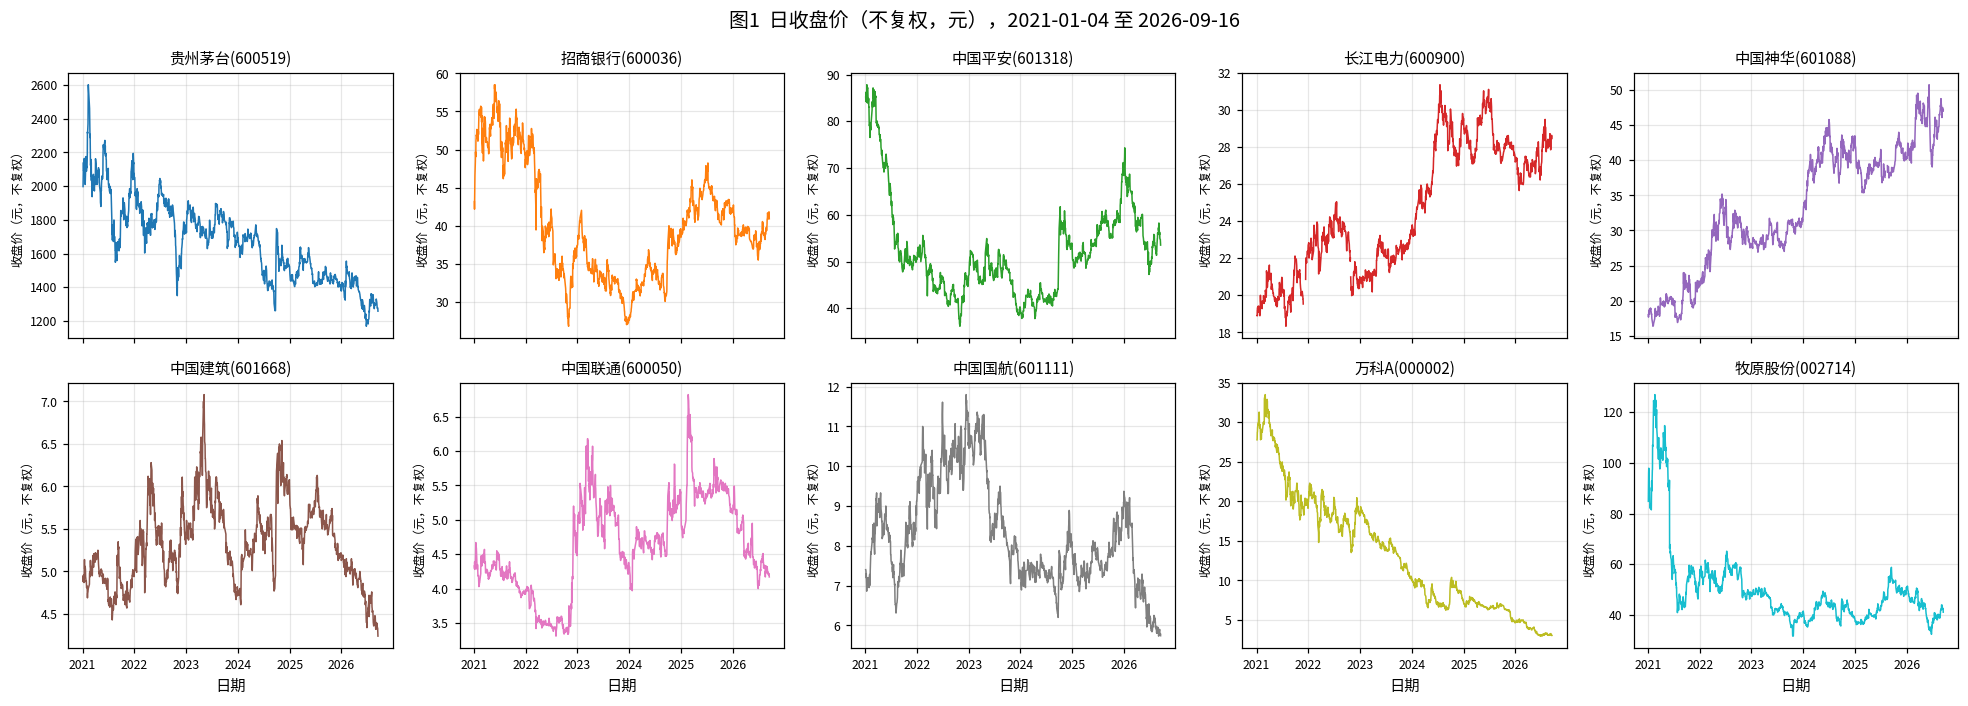

In [8]:
PAL = dict(zip(STOCKS, sns.color_palette("tab10", 10)))
def fmt_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig, axes = plt.subplots(2, 5, figsize=(18, 6.5), sharex=True)
for ax, s in zip(axes.flat, STOCKS):
    ax.plot(CLOSE.index, CLOSE[s], color=PAL[s], lw=1)
    ax.set_title(LABEL[s], fontsize=10); ax.set_ylabel("收盘价（元，不复权）", fontsize=8)
    fmt_date_axis(ax); ax.tick_params(labelsize=8); ax.grid(alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel("日期")
fig.suptitle("图1  日收盘价（不复权，元），2021-01-04 至 2026-09-16", fontsize=13)
fig.tight_layout(); fig.savefig(FIG / "fig1_unadjusted_close.png"); plt.show()

**解读（图 1）。** 不复权价格的水平差异极大：贵州茅台约 1,150—2,600 元，中国联通、中国国航、万科A 只有几元到十几元，所以只能比较收益率，不能比较价格。牧原股份 2021-06 的“断崖”是送转除权造成的，中国神华、长江电力在除息日也有台阶式下跌，这些都不是投资损失。

**核心发现：**
- 价格水平不可比，价格序列中含有除权除息造成的非经济性跳变；
- 这说明图 2 和后续计算必须使用全收益口径。

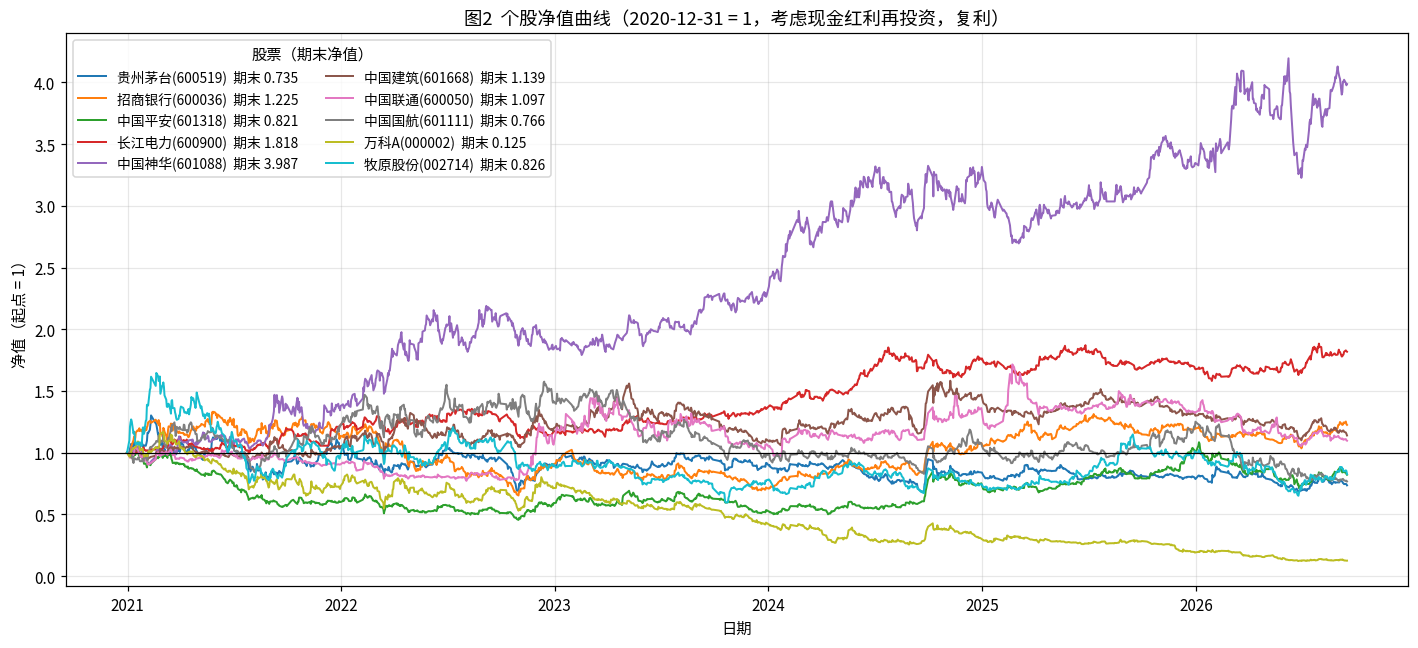

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))
for s in STOCKS:
    ax.plot(WEALTH.index, WEALTH[s], lw=1.3, color=PAL[s], label=f"{LABEL[s]}  期末 {WEALTH[s].iloc[-1]:.3f}")
ax.axhline(1, color="k", lw=0.8)
ax.set_title("图2  个股净值曲线（2020-12-31 = 1，考虑现金红利再投资，复利）")
ax.set_xlabel("日期"); ax.set_ylabel("净值（起点 = 1）")
fmt_date_axis(ax); ax.grid(alpha=0.3)
ax.legend(ncol=2, fontsize=9, loc="upper left", title="股票（期末净值）")
fig.tight_layout(); fig.savefig(FIG / "fig2_wealth_index.png"); plt.show()

**解读（图 2）。** 期末净值分化极大：中国神华 3.987（累计 +298.7%）、长江电力 1.818、招商银行 1.225、中国建筑 1.139、中国联通 1.097 大于 1；牧原股份 0.826、中国平安 0.821、中国国航 0.766、贵州茅台 0.735、万科A 0.125 小于 1。中国神华的上涨贯穿 2021—2024 年，万科A 则几乎单边下跌。一种可能的解释是高股息资源股受到市场偏好，而房地产行业在去杠杆，但本作业不能检验这种因果关系。这一排序是事后结果，不影响 §2 的事前选股。

**核心发现：**
- 10 只中 5 只净值大于 1，首尾相差约 3.9 倍净值；
- 行业间的路径差异明显，为组合分散化提供了空间。

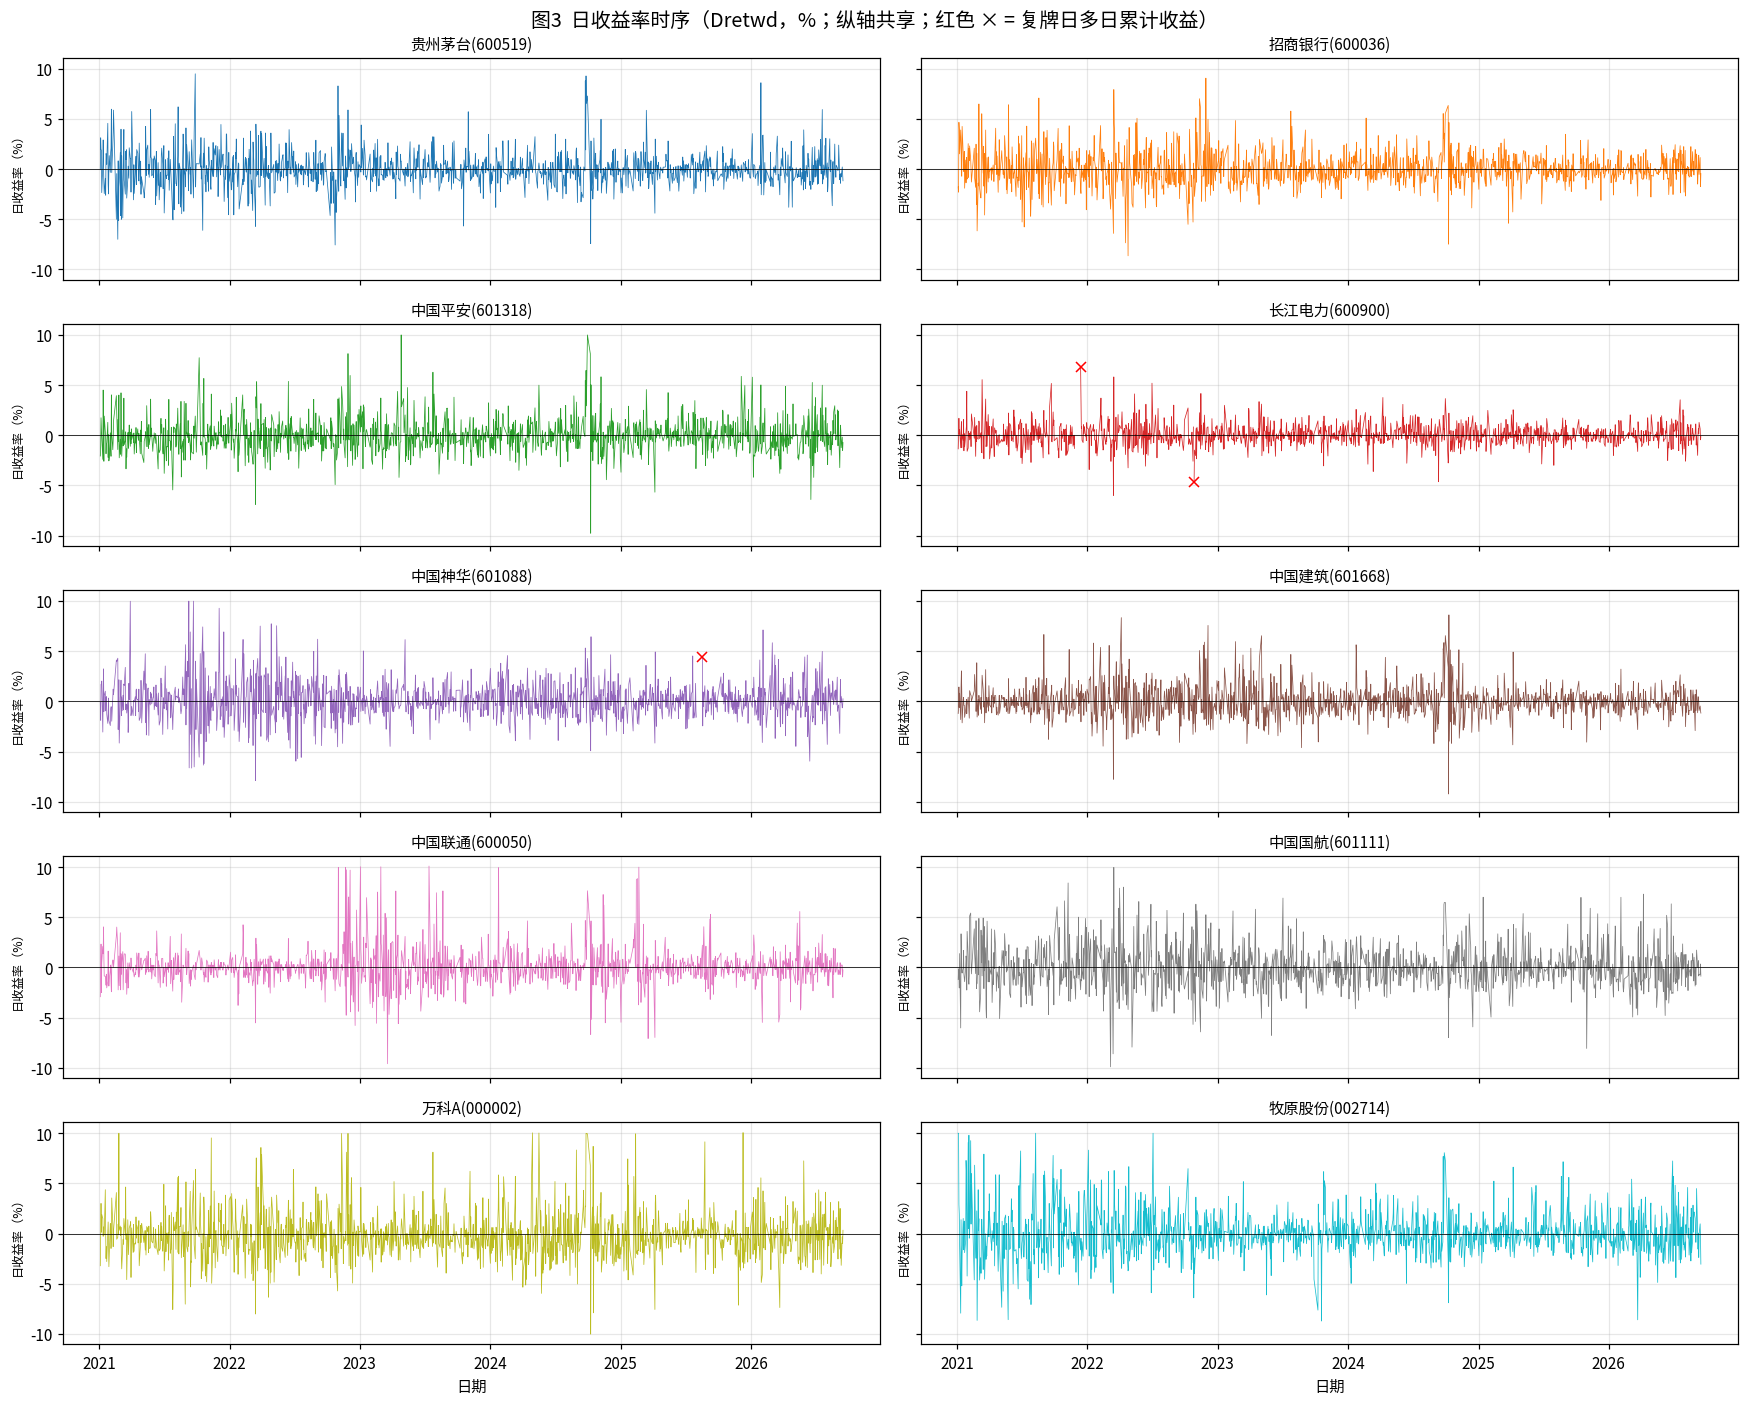

,Stkcd,股票,Trddt,prev_close,Clsprc,Dretnd,Dretwd,is_resume_day,分红除息日
4856,600050,中国联通(600050),2023-07-14,4.6500,5.1200,0.1011,0.1011,False,False
1219,000002,万科A(000002),2025-12-10,4.7700,5.2500,0.1006,0.1006,False,False
4729,600050,中国联通(600050),2023-01-03,4.4800,4.9300,0.1004,0.1004,False,False
826,000002,万科A(000002),2024-04-29,6.8700,7.5600,0.1004,0.1004,False,False
4765,600050,中国联通(600050),2023-03-01,5.2800,5.8100,0.1004,0.1004,False,False
837,000002,万科A(000002),2024-05-17,8.1800,9.0000,0.1002,0.1002,False,False
932,000002,万科A(000002),2024-10-09,10.3800,9.3400,-0.1002,-0.1002,False,False
1575,002714,牧原股份(002714),2021-08-09,42.2800,46.5100,0.1000,0.1000,False,False
56,000002,万科A(000002),2021-02-25,29.9900,32.9900,0.1000,0.1000,False,False
11819,601318,中国平安(601318),2023-04-27,45.7900,50.3700,0.1000,0.1000,False,False


非复牌日 |Dretnd| > 10.05%（看似超出 ±10% 涨跌停）: 4


,Stkcd,Trddt,prev_close,Clsprc,Dretnd,Dretwd,股票,分红除息日
1219,000002,2025-12-10,4.7700,5.2500,0.1006,0.1006,万科A(000002),False
4856,600050,2023-07-14,4.6500,5.1200,0.1011,0.1011,中国联通(600050),False
8579,601088,2021-07-12,19.9800,17.6200,-0.1181,-0.0275,中国神华(601088),True
8820,601088,2022-07-11,33.4500,29.0000,-0.1330,-0.0571,中国神华(601088),True


In [10]:
fig, axes = plt.subplots(5, 2, figsize=(16, 13), sharex=True, sharey=True)
for ax, s in zip(axes.flat, STOCKS):
    ax.plot(RET_H.index, 100 * RET_H[s], lw=0.5, color=PAL[s])
    for (ss, d) in RESUME:
        if ss == s:
            ax.plot(d, 100 * RET_H.loc[d, s], "rx", ms=6)
    ax.set_title(LABEL[s], fontsize=10); ax.set_ylabel("日收益率（%）", fontsize=8)
    ax.axhline(0, color="k", lw=0.5); ax.grid(alpha=0.3); fmt_date_axis(ax)
for ax in axes[-1]:
    ax.set_xlabel("日期")
fig.suptitle("图3  日收益率时序（Dretwd，%；纵轴共享；红色 × = 复牌日多日累计收益）", fontsize=13)
fig.tight_layout(); fig.savefig(FIG / "fig3_daily_returns.png"); plt.show()

ext = panel.loc[panel["Dretwd"].abs().sort_values(ascending=False).index[:12],
                ["Stkcd", "Trddt", "prev_close", "Clsprc", "Dretnd", "Dretwd", "is_resume_day"]].copy()
ext.insert(1, "股票", ext.Stkcd.map(LABEL))
ext["分红除息日"] = ext.index.isin(div_days.index)
ext.to_csv(QA / "extreme_daily_returns.csv", index=False, encoding="utf-8-sig")
display(ext)
lim = panel[(panel.Dretnd.abs() > 0.1005) & ~panel.is_resume_day]
print("非复牌日 |Dretnd| > 10.05%（看似超出 ±10% 涨跌停）:", len(lim))
display(lim[["Stkcd", "Trddt", "prev_close", "Clsprc", "Dretnd", "Dretwd"]].assign(股票=lambda d: d.Stkcd.map(LABEL),
        分红除息日=lim.index.isin(div_days.index)))

**解读（图 3 与异常收益）。**
- 日收益呈现明显的波动聚集，2024 年 9 月底—10 月各股同时出现大幅正负收益。
- 绝对值最大的日收益都在 ±10% 涨跌停附近，主要来自万科A、中国联通、牧原股份、中国平安。
- 非复牌日有 4 个观测的 |`Dretnd`| 超过 10.05%，都有正常解释：
  - 万科A 2025-12-10（+10.06%）和中国联通 2023-07-14（+10.11%）是低价股的涨停价四舍五入到 0.01 元造成的，例如 4.65×1.1 = 5.115，取整为 5.12；
  - 中国神华 2021-07-12 和 2022-07-11 是大额分红的除息日，这两天的 `Dretwd` 分别只有 −2.75% 和 −5.71%。

**核心发现：**
- 没有发现数据错误，极端值来自涨跌停、政策冲击和除息，因此**保留全部观测，不做缩尾**；
- 复牌日收益在图中单独标出，不计入单日统计。

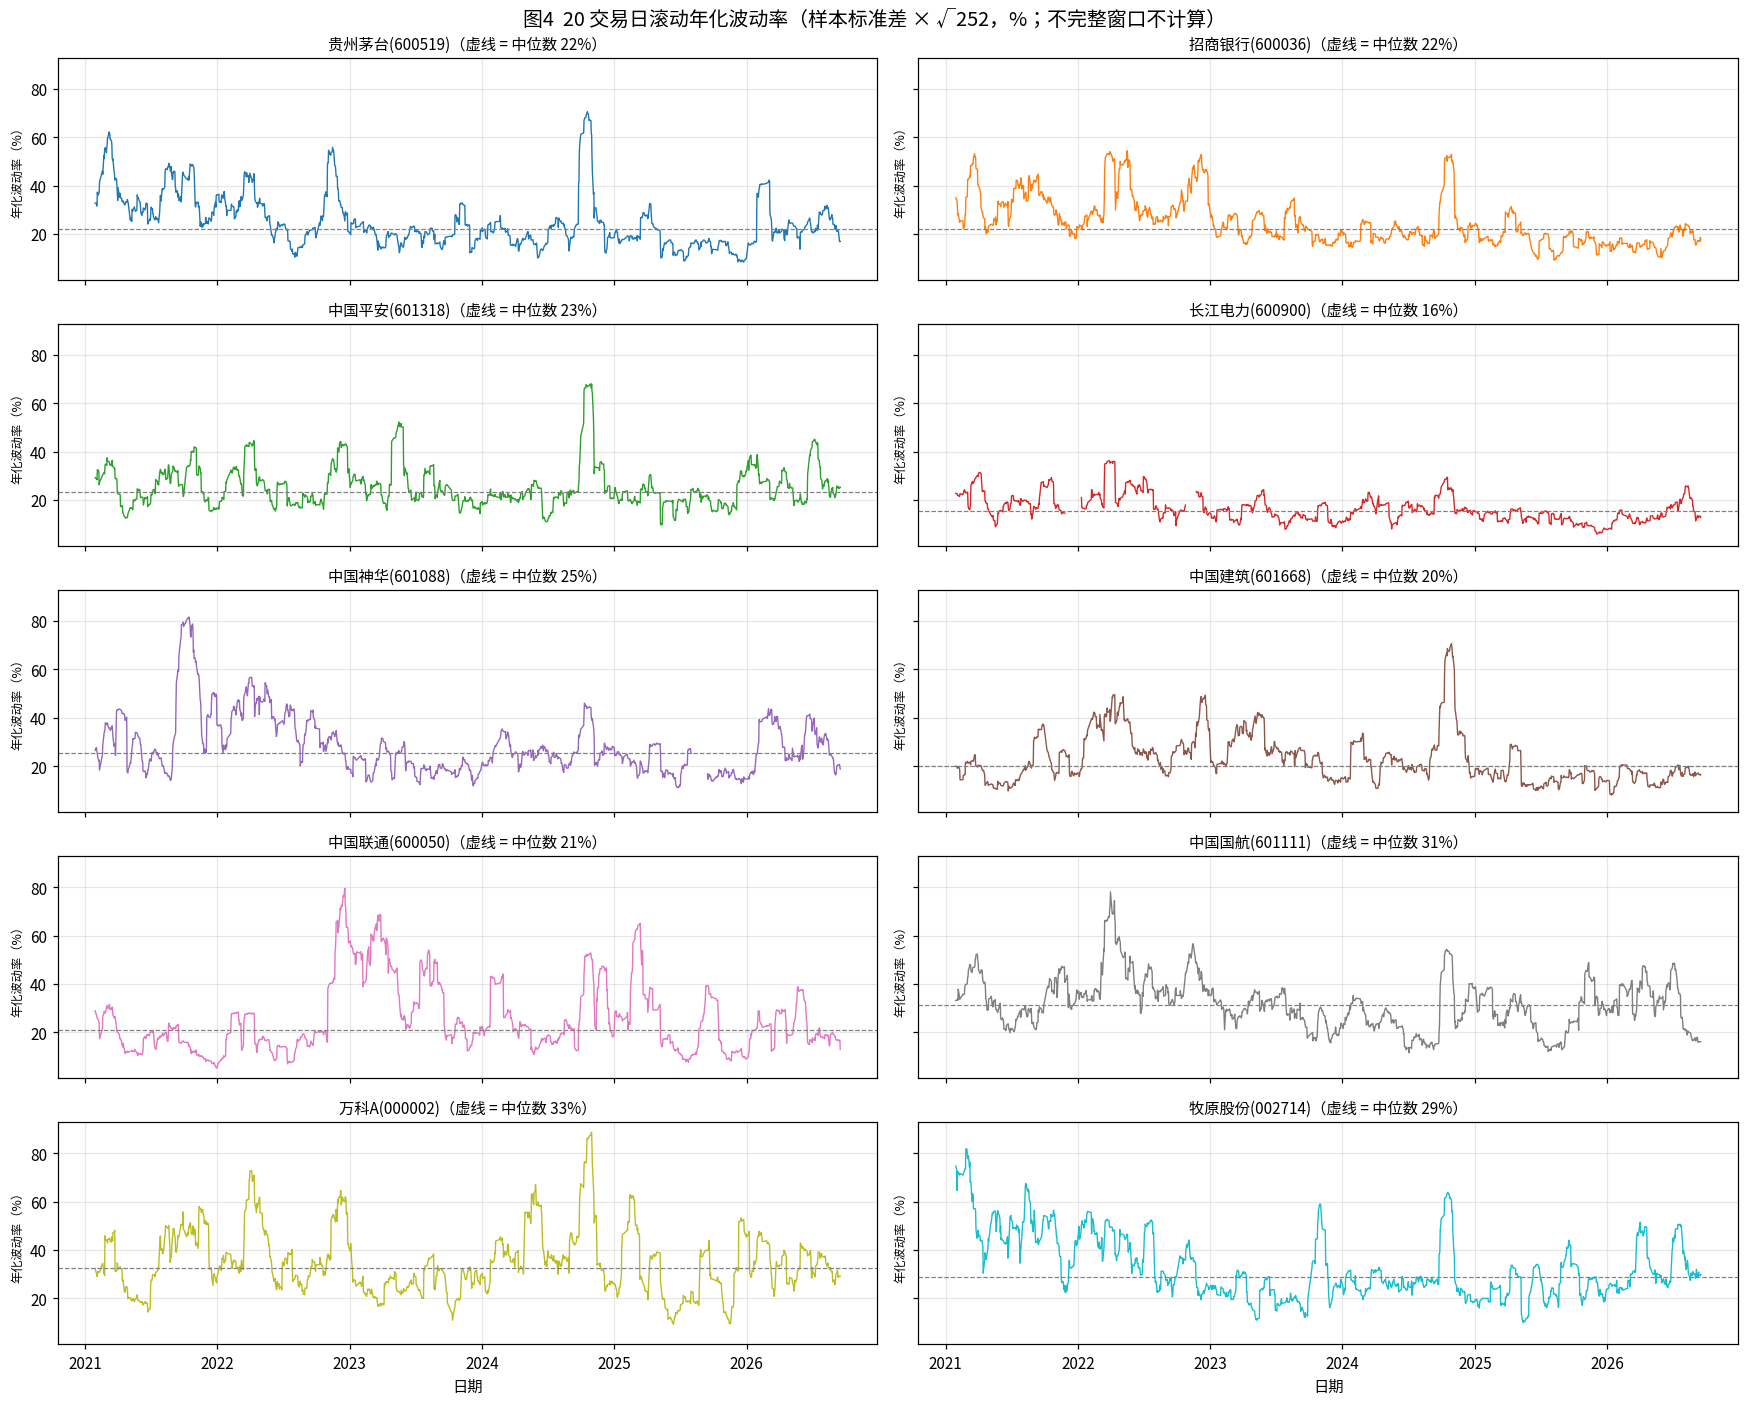

,有效窗口数,中位数%,最高%,最高出现日,最低%
Stkcd,,,,,
万科A(000002),1365,32.7076,88.7148,2024-10-29,9.2902
中国国航(601111),1365,31.0974,78.0185,2022-04-01,11.5168
牧原股份(002714),1365,28.7440,81.8070,2021-02-26,9.9251
中国神华(601088),1335,25.4093,81.7034,2021-10-15,11.1333
中国平安(601318),1365,23.2147,67.9659,2024-10-30,9.6164
贵州茅台(600519),1365,22.2176,70.5641,2024-10-18,8.3544
招商银行(600036),1365,22.1258,54.3894,2022-05-17,9.0930
中国联通(600050),1365,20.8094,79.5013,2022-12-19,5.2145
中国建筑(601668),1365,20.0140,70.7023,2024-10-28,7.9981


In [11]:
# 严格 20 交易日窗口：窗口内任一天缺少单日收益（停牌/复牌）则该窗口不计算
vol20 = RET_1D.rolling(window=20, min_periods=20).std(ddof=1) * np.sqrt(ANN)
fig, axes = plt.subplots(5, 2, figsize=(16, 13), sharex=True, sharey=True)
for ax, s in zip(axes.flat, STOCKS):
    ax.plot(vol20.index, 100 * vol20[s], lw=0.9, color=PAL[s])
    ax.axhline(100 * vol20[s].median(), color="grey", ls="--", lw=0.8)
    ax.set_title(f"{LABEL[s]}（虚线 = 中位数 {100*vol20[s].median():.0f}%）", fontsize=10)
    ax.set_ylabel("年化波动率（%）", fontsize=8); ax.grid(alpha=0.3); fmt_date_axis(ax)
for ax in axes[-1]:
    ax.set_xlabel("日期")
fig.suptitle("图4  20 交易日滚动年化波动率（样本标准差 × √252，%；不完整窗口不计算）", fontsize=13)
fig.tight_layout(); fig.savefig(FIG / "fig4_rolling_vol20.png"); plt.show()
peak = pd.DataFrame({"有效窗口数": vol20.count(), "中位数%": 100 * vol20.median(), "最高%": 100 * vol20.max(),
                     "最高出现日": vol20.idxmax().dt.date, "最低%": 100 * vol20.min()}).rename(index=LABEL)
display(peak.sort_values("中位数%", ascending=False))

**解读（图 4）。** 按中位数排序，万科A 的滚动波动率最高（32.7%），其后是中国国航（31.1%）和牧原股份（28.7%）；长江电力最低（15.6%），它的最高值也只有 36.3%。多只股票的峰值集中在 2024 年 10 月下旬：万科A 88.7%（10-29）、中国平安 68.0%（10-30）、贵州茅台 70.6%（10-18）、中国建筑 70.7%（10-28），说明这是一次全市场的波动冲击。其余峰值是个股或行业层面的，例如中国神华 2021-10-15、中国国航 2022-04-01。长江电力与中国神华的有效窗口数较少（1,314 和 1,335，其余 1,365），因为包含停牌日或复牌日的窗口被剔除了。

**核心发现：**
- 波动率随时间变化很大，同一股票的最低与最高滚动波动率相差约 6—15 倍，例如中国联通为 5.2% 对 79.5%；
- 2024 年 10 月是全样本的共同高波动期；
- 严格的 20 日窗口避免了复牌日多日收益虚增波动。

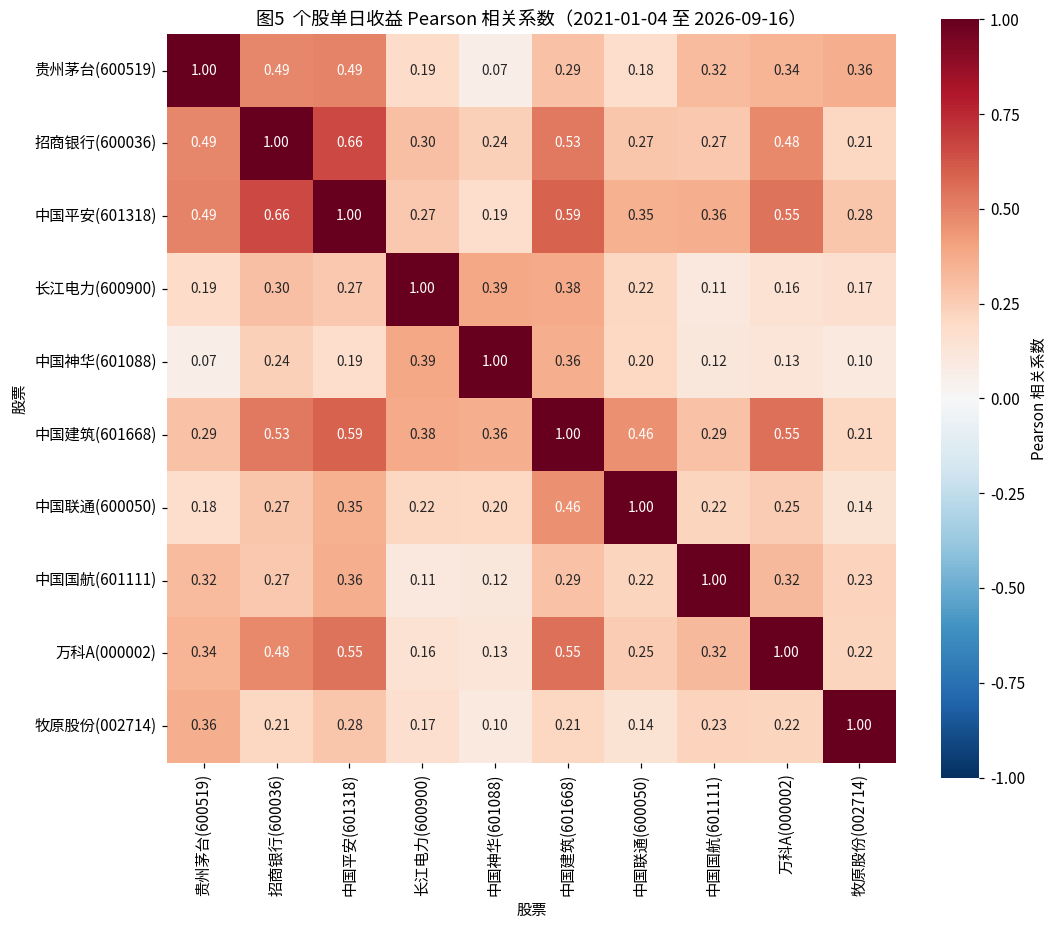

45 对相关系数：均值 0.300，中位数 0.274，最小 0.065，最大 0.658


,相关系数
招商银行(600036) – 中国建筑(601668),0.5288
中国平安(601318) – 万科A(000002),0.5455
中国建筑(601668) – 万科A(000002),0.5511
中国平安(601318) – 中国建筑(601668),0.5887
招商银行(600036) – 中国平安(601318),0.6577
贵州茅台(600519) – 中国神华(601088),0.0654
中国神华(601088) – 牧原股份(002714),0.1014
长江电力(600900) – 中国国航(601111),0.1087
中国神华(601088) – 中国国航(601111),0.1158
中国神华(601088) – 万科A(000002),0.1299


In [12]:
corr = RET_1D.corr(method="pearson", min_periods=200)
fig, ax = plt.subplots(figsize=(10, 8.5))
sns.heatmap(corr.rename(index=LABEL, columns=LABEL), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Pearson 相关系数"}, ax=ax, annot_kws={"size": 9})
ax.set_title("图5  个股单日收益 Pearson 相关系数（2021-01-04 至 2026-09-16）")
ax.set_xlabel("股票"); ax.set_ylabel("股票")
fig.tight_layout(); fig.savefig(FIG / "fig5_corr_heatmap.png"); plt.show()
off = corr.where(np.triu(np.ones(corr.shape, bool), k=1)).stack().dropna()
print("45 对相关系数：均值 %.3f，中位数 %.3f，最小 %.3f，最大 %.3f" % (off.mean(), off.median(), off.min(), off.max()))
show = pd.concat([off.sort_values().tail(5), off.sort_values().head(5)])
show.index = [f"{LABEL[a]} – {LABEL[b]}" for a, b in show.index]
display(show.rename("相关系数").to_frame())
corr.to_csv(TAB / "corr_matrix.csv", encoding="utf-8-sig")

**解读（图 5）。** 45 对单日收益相关系数全部为正，均值 0.300，中位数 0.274，范围 0.065—0.658。相关最高的 5 对都在“金融—地产—建筑”一簇：招商银行–中国平安 0.658、中国平安–中国建筑 0.589、中国建筑–万科A 0.551、中国平安–万科A 0.546、招商银行–中国建筑 0.529。相关最低的几对都涉及中国神华或防御型资产，例如贵州茅台–中国神华只有 0.065，长江电力–中国国航 0.109。这些模式与行业共同的信贷和地产周期敞口相符，但只是相关，不是因果。

**核心发现：**
- 所有股票都受共同的市场因子影响，但相关程度远低于 1，分散化有效；
- 金融—地产—建筑的相关性高，分散效果有限；中国神华与其他股票相关最低，是主要的分散化来源。

## 6. 个股描述统计

本节用统计量概括 10 只股票的收益分布与风险，并检查结果是否合理。

- 均值、标准差、最小值、中位数、最大值、偏度、超额峰度（Fisher 定义，正态分布为 0）：都基于**单日收益 `RET_1D`**；
- 累计收益、几何年化收益、最大回撤：基于持仓期路径 `R0`（停牌日为 0，复牌日计入多日收益），年化统一用市场交易日数 T = 1,384；
- 年化波动 = 单日收益样本标准差 × √252。

In [13]:
def max_drawdown(r, base_date):
    """r：日收益序列。净值起点 W_0 = 1（base_date）也作为峰值候选。返回 (最大回撤 ≥ 0, 峰值日, 谷底日)。"""
    w = pd.concat([pd.Series([1.0], index=[base_date]), (1 + r).cumprod()])
    dd = w / w.cummax() - 1
    trough = dd.idxmin()
    return -dd.min(), w.loc[:trough].idxmax(), trough

rows = []
for s in STOCKS:
    r1 = RET_1D[s].dropna()
    mdd, pk, tr = max_drawdown(R0[s], base_day)
    cumr = (1 + R0[s]).prod() - 1
    rows.append({"股票": LABEL[s], "N(单日)": r1.size, "均值%": 100 * r1.mean(), "标准差%": 100 * r1.std(),
                 "最小值%": 100 * r1.min(), "中位数%": 100 * r1.median(), "最大值%": 100 * r1.max(),
                 "偏度": r1.skew(), "超额峰度": r1.kurt(), "累计收益%": 100 * cumr,
                 "几何年化%": 100 * ((1 + cumr) ** (ANN / T) - 1), "年化波动%": 100 * r1.std() * np.sqrt(ANN),
                 "最大回撤%": 100 * mdd, "回撤峰值日": pk.date(), "回撤谷底日": tr.date()})
desc = pd.DataFrame(rows).set_index("股票")
desc.to_csv(TAB / "stock_descriptive_stats.csv", encoding="utf-8-sig")
display(desc.round(3))

,N(单日),均值%,标准差%,最小值%,中位数%,最大值%,偏度,超额峰度,累计收益%,几何年化%,年化波动%,最大回撤%,回撤峰值日,回撤谷底日
股票,,,,,,,,,,,,,,
贵州茅台(600519),1384,-0.0080,1.7170,-7.5570,-0.0950,9.5040,0.5840,4.3330,-26.4970,-5.4510,27.2510,47.5490,2021-02-10,2026-06-26
招商银行(600036),1384,0.0290,1.6890,-8.6350,-0.0710,9.0740,0.2990,3.3010,22.5000,3.7640,26.8180,50.9530,2021-05-26,2022-10-31
中国平安(601318),1384,0.0000,1.7090,-9.7680,-0.1140,10.0020,0.7310,4.2820,-17.9310,-3.5340,27.1280,54.9450,2021-01-12,2022-10-31
长江电力(600900),1371,0.0480,1.0870,-6.0000,0.0000,5.8160,0.4050,3.2940,81.8020,11.4980,17.2560,17.5400,2022-08-12,2022-11-03
中国神华(601088),1373,0.1160,1.9180,-7.9010,0.0460,9.9950,0.5100,3.3170,298.7370,28.6390,30.4480,23.0890,2026-06-08,2026-06-30
中国建筑(601668),1384,0.0220,1.5640,-9.2330,0.0000,8.6210,0.6510,4.4440,13.9180,2.4010,24.8300,32.0210,2023-05-08,2024-01-22
中国联通(600050),1384,0.0230,1.8410,-9.5940,0.0000,10.1080,1.2860,8.0450,9.6800,1.6970,29.2180,38.6650,2025-02-21,2026-06-30
中国国航(601111),1384,0.0030,2.0940,-9.9030,-0.1330,9.9760,0.3920,2.2440,-23.3660,-4.7300,33.2460,51.4420,2022-12-14,2026-09-02
万科A(000002),1384,-0.1230,2.3460,-10.0190,-0.2780,10.0630,0.8530,3.3980,-87.5310,-31.5510,37.2390,89.6000,2021-03-03,2026-06-25


**解读。** 日均收益都很小，从 −0.123%（万科A）到 +0.116%（中国神华）。10 只中有 9 只的中位数 ≤ 0，但偏度全部为正（0.30—1.29），超额峰度在 2.24—8.05 之间，说明日收益分布“多数日子小跌、少数日子大涨”，而且是厚尾。单日年化波动从 17.3%（长江电力）到 37.2%（万科A）。最大回撤最大的是万科A 的 89.6%（2021-03-03 → 2026-06-25），最小的是长江电力的 17.5%。剔除复牌日以后，长江电力的最大单日收益从 +6.81% 降到 +5.82%，年化波动从 17.6% 降到 17.3%，说明区分单日收益与多日收益是有必要的。

**合理性检查：** 牧原股份的日均收益为 +0.012%，但累计收益为 −17.4%，这是“波动拖累”造成的：几何收益约等于 $\bar r-\sigma^2/2$，而 $0.0227^2/2\approx0.026\%$，大于日均收益。这说明必须使用几何年化。

**核心发现：**
- 日收益正偏、厚尾，不服从正态分布；
- 在本样本中高波动没有带来高收益：万科A 波动最高、收益最差，长江电力波动最低、年化 11.5%。这只是一次样本实现，不能据此否定风险溢价；
- 年化必须用几何口径，否则会高估收益。

## 7. 组合构建

本节构建两个组合，并检验市值权重没有前视信息。按官方的教学设定：**每日按目标权重计算组合收益，忽略交易成本**。

- **等权组合：** $r^{EW}_{p,t}=\sum_i 0.1\,r_{i,t}$，相当于每天开盘时把每只股票的权重调回 10%；
- **市值加权组合：** $r^{VW}_{p,t}=\sum_i w_{i,t-1}r_{i,t}$，其中 $w_{i,t-1}=MV_{i,t-1}/\sum_j MV_{j,t-1}$，$MV$ 为 CSMAR 总市值 `Dsmvtll`，t−1 指上一个市场交易日。股票在 t−1 停牌时，沿用停牌前最后一个市值，这是 t−1 时已知的信息；
- **停牌日：** $r_{i,t}=0$，持仓价值不变；复牌日计入多日收益。这只适用于 §3 中已识别的 21 个停牌日，不是把所有缺失一律填 0；
- **检查：** 每日权重和为 1；用 `shift(1)` 与“显式按上一交易日合并”两种算法交叉验证权重；两个组合使用同一日期索引；计算 HHI 与有效持股数 1/HHI。

权重和：最小 1.000000000000000，最大 1.000000000000000，最大|偏离| 4.4e-16
评价期：2021-01-04 → 2026-09-16，T = 1384，两组合日期索引相同: True；首日权重使用 2020-12-31 的市值


,平均权重%,最小%,最大%,期初%,期末%
Stkcd,,,,,
贵州茅台(600519),38.2265,30.2921,45.8302,41.2739,30.4091
招商银行(600036),15.0294,11.4389,20.5536,14.9093,16.2047
长江电力(600900),10.7923,6.2809,14.8345,7.1654,13.3281
中国平安(601318),10.2540,7.8313,15.4945,15.4945,10.9817
中国神华(601088),10.2428,3.8699,17.9870,4.8841,16.4426
牧原股份(002714),4.7151,3.4561,6.9473,4.7518,4.4238
中国建筑(601668),4.0664,2.8254,5.3412,3.4298,3.3880
中国联通(600050),2.6723,1.7777,4.0616,2.2748,2.4978
万科A(000002),2.2801,0.5613,5.0164,4.5894,0.5613


VW 的 HHI：均值 0.211（等权 = 0.100）；有效持股数 1/HHI：均值 4.79，范围 3.82—5.63
等权每日再平衡的单边换手：日均 0.522%，年化约 131%（本文按官方设定不扣交易成本）


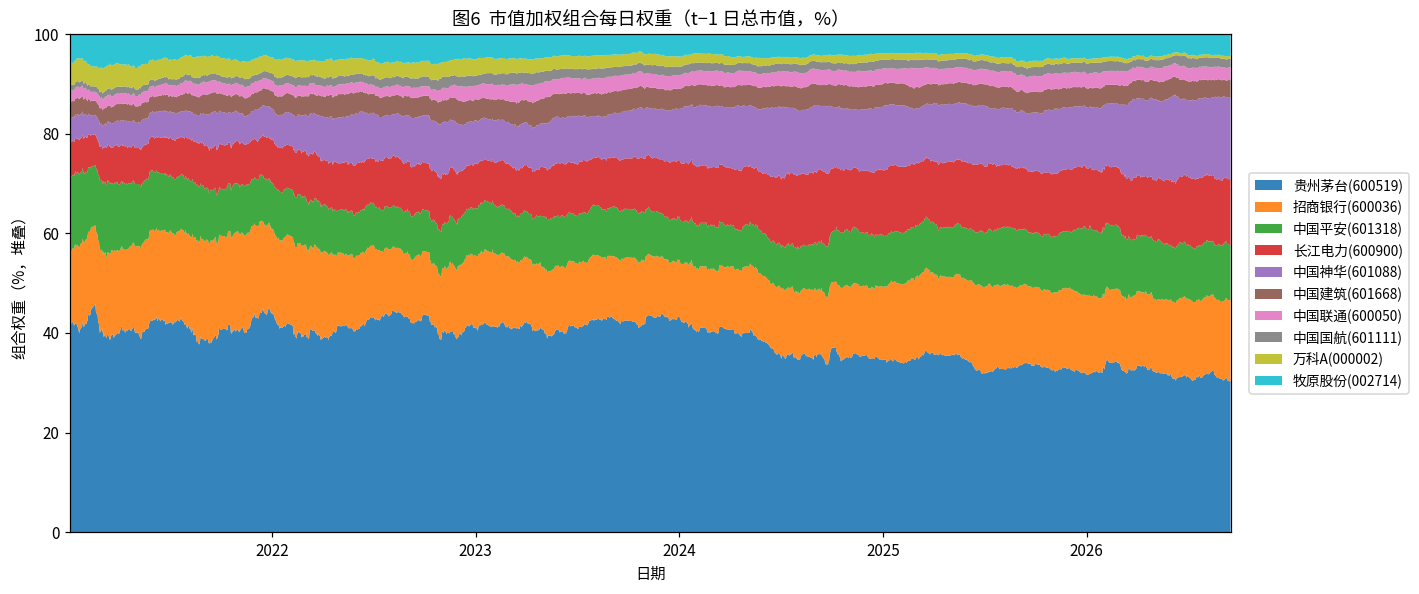

In [14]:
MV_all = trd.pivot(index="Trddt", columns="Stkcd", values="Dsmvtll").reindex(CAL)[STOCKS].ffill()
W_vw = MV_all.shift(1).div(MV_all.shift(1).sum(axis=1), axis=0).reindex(CAL_S)     # 第 t 行 = t−1 市值权重
prev_day = pd.Series(CAL[:-1], index=CAL[1:])
W_check = MV_all.loc[prev_day.reindex(CAL_S).values].set_axis(CAL_S)
W_check = W_check.div(W_check.sum(axis=1), axis=0)
assert np.allclose(W_vw.values, W_check.values) and W_vw.notna().all().all()

r_ew = R0.mul(0.1).sum(axis=1).rename("等权组合")
r_vw = (W_vw * R0).sum(axis=1).rename("市值加权组合(t−1)")
wsum = W_vw.sum(axis=1)
assert r_ew.index.equals(r_vw.index) and len(r_ew) == T
print("权重和：最小 %.15f，最大 %.15f，最大|偏离| %.1e" % (wsum.min(), wsum.max(), (wsum - 1).abs().max()))
print("评价期：%s → %s，T = %d，两组合日期索引相同: %s；首日权重使用 %s 的市值"
      % (r_ew.index[0].date(), r_ew.index[-1].date(), T, r_ew.index.equals(r_vw.index), prev_day.loc[CAL_S[0]].date()))

HHI = (W_vw ** 2).sum(axis=1)
wstat = pd.DataFrame({"平均权重%": 100 * W_vw.mean(), "最小%": 100 * W_vw.min(), "最大%": 100 * W_vw.max(),
                      "期初%": 100 * W_vw.iloc[0], "期末%": 100 * W_vw.iloc[-1]}).rename(index=LABEL)
display(wstat.sort_values("平均权重%", ascending=False))
print("VW 的 HHI：均值 %.3f（等权 = 0.100）；有效持股数 1/HHI：均值 %.2f，范围 %.2f—%.2f"
      % (HHI.mean(), (1 / HHI).mean(), (1 / HHI).min(), (1 / HHI).max()))
drift = (0.1 * (1 + R0)).div(1 + r_ew, axis=0)
turn = 0.5 * (drift - 0.1).abs().sum(axis=1)
print("等权每日再平衡的单边换手：日均 %.3f%%，年化约 %.0f%%（本文按官方设定不扣交易成本）" % (100 * turn.mean(), 100 * turn.mean() * ANN))
W_vw.to_csv(PROC / "vw_weights_tminus1.csv", encoding="utf-8-sig")
pd.concat([r_ew, r_vw], axis=1).to_csv(PROC / "portfolio_daily_returns.csv", encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.stackplot(W_vw.index, (100 * W_vw.T).values, labels=[LABEL[s] for s in STOCKS], colors=[PAL[s] for s in STOCKS], alpha=0.9)
ax.set_ylim(0, 100); ax.set_xlim(W_vw.index[0], W_vw.index[-1])
ax.set_title("图6  市值加权组合每日权重（t−1 日总市值，%）")
ax.set_xlabel("日期"); ax.set_ylabel("组合权重（%，堆叠）"); fmt_date_axis(ax)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)
fig.tight_layout(); fig.savefig(FIG / "fig6_vw_weights.png"); plt.show()

**解读。**
- 两个组合的日期索引完全相同：T = 1,384，2021-01-04 至 2026-09-16。首日权重使用 2020-12-31 的市值，每日权重和与 1 的偏差只有浮点误差量级；两种算法得到的权重一致，说明没有前视信息。
- 市值加权组合高度集中：贵州茅台平均权重 38.2%，招商银行 15.0%，两者合计超过一半；HHI 均值约 0.21，有效持股数只有约 4.8，而等权组合为 10。
- 权重随股价表现漂移，例如中国神华从 4.9% 升到 16.4%，万科A 从 4.6% 降到 0.56%。
- 等权组合为了每天回到 10%，单边换手率年化约 131%；本文按官方设定没有扣除交易成本。

**核心发现：**
- t−1 权重正确，而且可复核；
- 市值加权组合实际上是一个集中于茅台和招行的组合，等权组合的分散程度更高。

## 8. 组合绩效比较

本节在同一评价期内比较两个组合的收益与风险，并给出稳健性检验。

| 指标 | 公式 |
|---|---|
| 期末净值 / 累计收益 | $W_T=\prod_{t=1}^T(1+r_{p,t})$；$W_T-1$ |
| 几何年化收益 | $W_T^{252/T}-1$ |
| 年化波动 | $\text{std}(r_{p,t})\times\sqrt{252}$ |
| 最大回撤（非负） | $\max_t(1-W_t/\max_{s\le t}W_s)$，$W_0=1$ |

- 用 $(1+R_{ann})^{T/252}=W_T$ 反向核对年化收益；
- 稳健性：同日市值（前视，错误示范）、停牌处理的替代方案、不含分红的收益。

,等权组合,市值加权组合(t−1)
T,1384,1384
期末净值,1.0928,1.0303
累计收益%,9.2766,3.0258
几何年化收益%,1.6284,0.5442
年化波动%,17.5449,18.6264
最大回撤%,22.6653,35.6772
回撤峰值日,2025-11-13,2021-02-10
回撤谷底日,2026-06-30,2022-10-31
期末前收复峰值,否,否
（对照）算术日均×252 %,3.1522,2.2737


两组合日收益相关系数 0.889；年化跟踪差异 8.57%


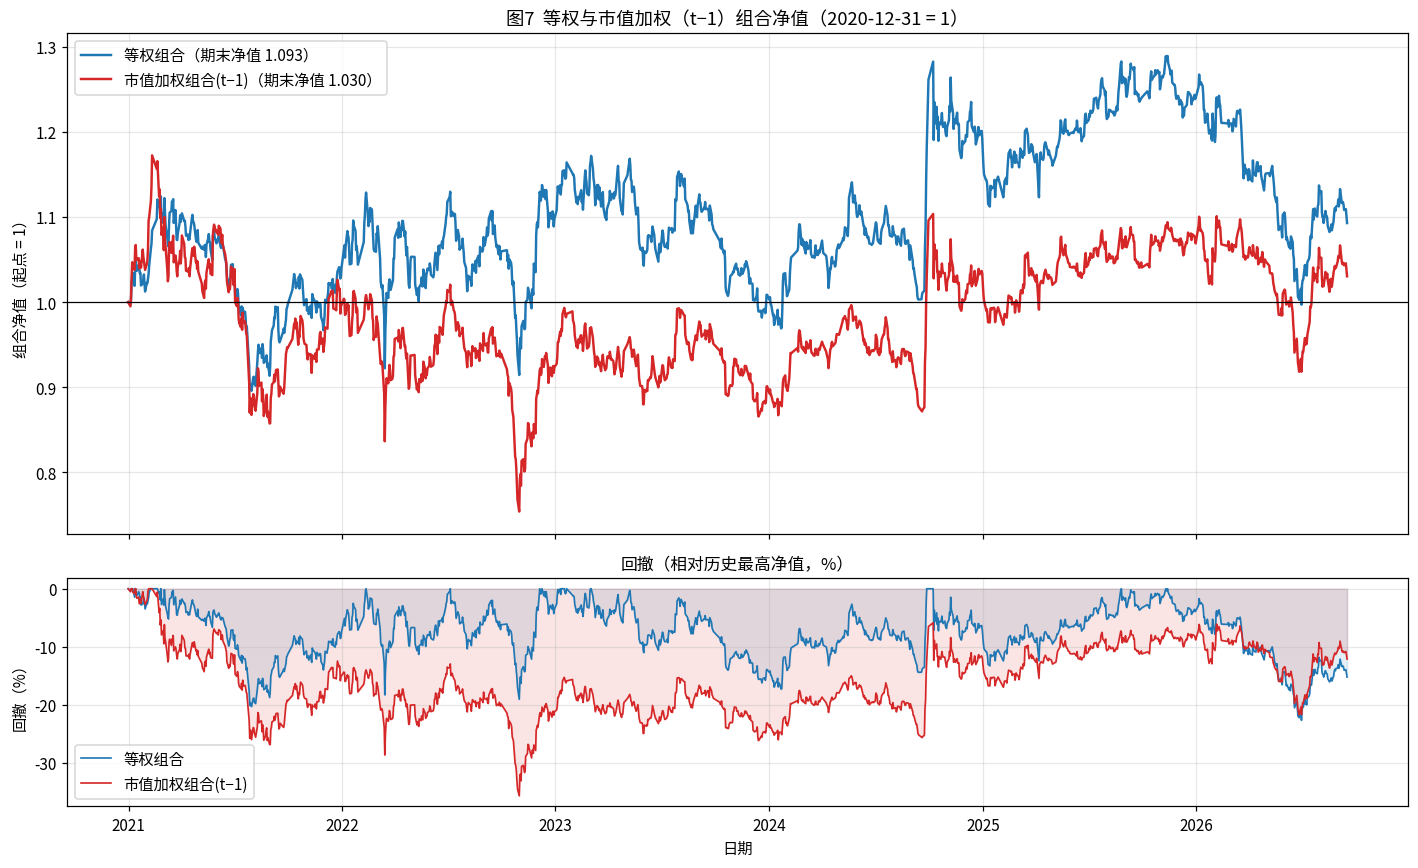

,等权组合,市值加权组合(t−1),EW−VW（百分点）
年份（2026 截至 09-16）,,,
2021,4.0200,-0.3500,4.3700
2022,5.4800,-7.3500,12.8300
2023,-8.0900,-2.3900,-5.6900
2024,18.1300,14.6700,3.4600
2025,4.0300,3.4300,0.6000
2026,-11.8400,-3.6100,-8.2200


,对 EW−VW 日收益差的贡献（百分点，算术加总）
Stkcd,
万科A(000002),-13.3000
招商银行(600036),-0.6700
长江电力(600900),0.1800
中国国航(601111),0.9000
中国平安(601318),2.0100
中国建筑(601668),2.0700
牧原股份(002714),2.4600
中国联通(600050),2.7300
中国神华(601088),2.8000


In [15]:
def perf(r):
    mdd, pk, tr = max_drawdown(r, base_day)
    WT = (1 + r).prod()
    ann = WT ** (ANN / len(r)) - 1
    assert np.isclose((1 + ann) ** (len(r) / ANN), WT)
    w = (1 + r).cumprod()
    rec = w.loc[tr:][w.loc[tr:] >= max(1.0, w.loc[:tr].max())]
    return pd.Series({"T": len(r), "期末净值": WT, "累计收益%": 100 * (WT - 1), "几何年化收益%": 100 * ann,
                      "年化波动%": 100 * r.std() * np.sqrt(ANN), "最大回撤%": 100 * mdd,
                      "回撤峰值日": pk.date(), "回撤谷底日": tr.date(), "期末前收复峰值": "是" if len(rec) else "否",
                      "（对照）算术日均×252 %": 100 * r.mean() * ANN})
perf_tab = pd.concat([perf(r_ew), perf(r_vw)], axis=1, keys=["等权组合", "市值加权组合(t−1)"])
perf_tab.to_csv(TAB / "portfolio_performance.csv", encoding="utf-8-sig")
display(perf_tab)
print("两组合日收益相关系数 %.3f；年化跟踪差异 %.2f%%" % (r_ew.corr(r_vw), 100 * (r_ew - r_vw).std() * np.sqrt(ANN)))

nav0 = pd.concat([pd.DataFrame([[1.0, 1.0]], columns=["等权组合", "市值加权组合(t−1)"], index=[base_day]),
                  pd.concat([(1 + r_ew).cumprod(), (1 + r_vw).cumprod()], axis=1)])
dd = nav0 / nav0.cummax() - 1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
cols = {"等权组合": "#1f77b4", "市值加权组合(t−1)": "#d62728"}
for c in nav0:
    ax1.plot(nav0.index, nav0[c], lw=1.6, color=cols[c], label=f"{c}（期末净值 {nav0[c].iloc[-1]:.3f}）")
    ax2.plot(dd.index, 100 * dd[c], lw=1.1, color=cols[c], label=c)
    ax2.fill_between(dd.index, 100 * dd[c], 0, color=cols[c], alpha=0.12)
ax1.axhline(1, color="k", lw=0.8)
ax1.set_title("图7  等权与市值加权（t−1）组合净值（2020-12-31 = 1）")
ax1.set_ylabel("组合净值（起点 = 1）"); ax1.legend(loc="upper left"); ax1.grid(alpha=0.3)
ax2.set_title("回撤（相对历史最高净值，%）", fontsize=11)
ax2.set_ylabel("回撤（%）"); ax2.set_xlabel("日期"); ax2.legend(loc="lower left"); ax2.grid(alpha=0.3)
fmt_date_axis(ax2)
fig.tight_layout(); fig.savefig(FIG / "fig7_portfolio_nav_drawdown.png"); plt.show()

yr = pd.concat([r_ew, r_vw], axis=1).groupby(r_ew.index.year).apply(lambda d: (1 + d).prod() - 1) * 100
yr["EW−VW（百分点）"] = yr.iloc[:, 0] - yr.iloc[:, 1]
yr.index.name = "年份（2026 截至 09-16）"
display(yr.round(2))
contrib = ((0.1 - W_vw) * R0).sum().mul(100).rename(index=LABEL).sort_values()
display(contrib.rename("对 EW−VW 日收益差的贡献（百分点，算术加总）").to_frame().round(2))

**解读（绩效）。** 在同一评价期内（T = 1,384）：

| | 等权 | 市值加权（t−1） |
|---|---|---|
| 期末净值 | **1.093** | 1.030 |
| 几何年化收益 | **1.63%** | 0.54% |
| 年化波动 | **17.54%** | 18.63% |
| 最大回撤 | **22.67%**（2025-11-13 → 2026-06-30） | 35.68%（2021-02-10 → 2022-10-31） |

- **分散化：** 10 只成分股的年化波动平均约为 29.0%，等权组合只有 17.54%，低约 40%。等权组合的波动低于其中 9 只，只比最稳定的长江电力（17.26%）略高。
- **年化方法：** 如果误用“日均×252”，等权组合的年化收益会被夸大为 3.15%。
- **分年度：** 等权组合在 2021、2022、2024、2025 年跑赢，市值加权组合在 2023 年和 2026 年（截至 09-16）跑赢，差异并不稳定。
- **差异来源：** 等权组合的优势主要来自低配下跌的贵州茅台（+5.65 个百分点）；超配万科A 则拖累了 13.3 个百分点。

**核心发现：**
- 本样本中等权组合收益更高、波动和回撤更小，但这是这 10 只股票特定表现的结果，不能推广为“等权必然更优”；
- 市值加权组合的风险主要来自对茅台的集中持仓；
- 截至 2026-09-16，两个组合都没有回到各自回撤前的峰值。

In [16]:
W_bad = MV_all.div(MV_all.sum(axis=1), axis=0).reindex(CAL_S)          # 错误示范：同日 t 市值
r_vw_bad = (W_bad * R0).sum(axis=1)
r_ew_alt = RET_H.mean(axis=1, skipna=True)                             # 停牌股权重平均分给其余股票
RET_nd = panel.pivot(index="Trddt", columns="Stkcd", values="Dretnd").reindex(CAL_S)[STOCKS].fillna(0)
r_ew_nd = RET_nd.mean(axis=1)                                          # 不含现金红利
rob = pd.concat([perf(r_vw), perf(r_vw_bad), perf(r_ew), perf(r_ew_alt), perf(r_ew_nd)], axis=1,
                keys=["VW t−1（主结果）", "VW 同日 t（前视，错误）", "EW 停牌日=0（主结果）", "EW 停牌股权重再分配", "EW 不含分红 Dretnd"])
display(rob.loc[["期末净值", "几何年化收益%", "年化波动%", "最大回撤%"]].astype(float).round(3))

,VW t−1（主结果）,VW 同日 t（前视，错误）,EW 停牌日=0（主结果）,EW 停牌股权重再分配,EW 不含分红 Dretnd
期末净值,1.0300,1.2900,1.0930,1.0960,0.8930
几何年化收益%,0.5440,4.7410,1.6280,1.6800,-2.0360
年化波动%,18.6260,18.6820,17.5450,17.5600,17.5740
最大回撤%,35.6770,29.0310,22.6650,22.6650,26.3880


**解读（稳健性）。**
- 如果误用同日市值，市值加权组合的期末净值会从 1.030 虚增到 1.290：当天上涨的股票当天的市值权重也更大，所以前视偏差会系统性地抬高收益。
- 停牌期间把该股权重分给其余股票，等权组合的期末净值只从 1.093 变为 1.096，停牌处理基本不影响结论。
- 如果忽略现金分红，等权组合的期末净值会降到 0.893，说明分红贡献了约 20 个百分点。

**核心发现：**
- t−1 权重是必要的，同日权重会带来约 26 个百分点的前视收益；
- 结论对停牌处理稳健，对是否计入分红高度敏感，所以必须使用 `Dretwd`。

## 9. 合理性检查汇总

| 检查项 | 结果 |
|---|---|
| 重复键 / 不可能值 / 缺失值 | 0 / 0 / 0 |
| 单位 | `Dsmvtll` 为千元，隐含股本核对一致 |
| 停牌 | 3 段共 21 个股票-日（从日历缺口推断，复牌价格旁证）；不插值 |
| 多日收益 | 3 个复牌日收益只进入持仓期计算，不进入单日统计 |
| 首个有效收益 | 2021-01-04，基准为 2020-12-31 |
| 看似超出涨跌停 | 4 个，分别为四舍五入（2 个）和除息日（2 个），不是数据错误 |
| 权重 | t−1 市值，两种算法一致，权重和为 1 |
| 评价期 | 两个组合同为 1,384 个交易日 |
| 年化与回撤 | 几何年化经反向核对；回撤以起点 1 为峰值候选，报告为非负数 |

## 10. 总体结论

2021-01-04 至 2026-09-16，10 只覆盖 9 个行业的大盘股表现高度分化：期末净值从中国神华的 3.987 到万科A 的 0.125，只有 5 只大于 1。日收益正偏、厚尾，波动率随时间大幅变化，2024 年 10 月是共同的高波动期。股票之间的相关性中等偏低（平均 0.30），“金融—地产—建筑”一簇相关最高，中国神华提供了主要的分散化。在同一个 1,384 天的评价期内，等权组合的期末净值为 1.093（几何年化 1.63%，波动 17.54%，最大回撤 22.67%），t−1 市值加权组合为 1.030（0.54%，18.63%，35.68%）。市值加权组合集中于茅台和招行（HHI 约 0.21，有效持股数约 4.8），因此风险更集中。

**核心发现：**
1. **收益口径决定结论：** 使用 `Dretwd` 以后，送转除权不再被误记为亏损；如果忽略分红，等权组合的期末净值会从 1.093 降到 0.893。
2. **前视偏差必须避免：** 用同日市值计算权重会把市值加权组合的净值虚增到 1.290；本文的 t−1 权重经过两种算法验证。
3. **等权组合在本样本中更优，但不能推广：** 优势主要来自低配下跌的茅台，同时超配万科带来 13 个百分点的拖累。这是特定持仓的结果，不能说明“等权必然更优”或存在小盘溢价。
4. **停牌处理对结论影响很小：** 21 个停牌日既不删除也不编造；3 个复牌日的多日收益只进入持仓期计算。

**局限：**
- 10 只股票是按“当前仍上市的龙头”选出的，有一定的幸存者偏差；
- 按官方设定每日再平衡且不计交易成本，而等权组合的年化换手约 131%；
- 停牌是从日历缺口推断的，数据中没有交易状态字段；
- 行业口径是 2015 年末的；没有计算夏普比率；
- 本分析是历史描述，**不构成对未来收益的预测或投资建议**。

In [17]:
import sys, platform
print("Python", sys.version.split()[0], "|", platform.platform())
for p in sorted((BASE / "outputs").rglob("*.*")):
    print("  ", p.relative_to(BASE))

Python 3.11.15 | Linux-6.18.44-fc-v37-x86_64-with-glibc2.39
   outputs/figures/fig1_unadjusted_close.png
   outputs/figures/fig2_wealth_index.png
   outputs/figures/fig3_daily_returns.png
   outputs/figures/fig4_rolling_vol20.png
   outputs/figures/fig5_corr_heatmap.png
   outputs/figures/fig6_vw_weights.png
   outputs/figures/fig7_portfolio_nav_drawdown.png
   outputs/qa/extreme_daily_returns.csv
   outputs/qa/raw_zip_inventory.csv
   outputs/qa/suspension_spells.csv
   outputs/tables/corr_matrix.csv
   outputs/tables/portfolio_performance.csv
   outputs/tables/stock_descriptive_stats.csv
   outputs/tables/stock_selection.csv
